In [1]:
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from src.data.data_loader import load_pupil_data
from src.utils.utilities import detect_and_interpolate_sudden_changes, normalize_series, detect_sudden_change_events, moving_average, normalize_mean_std

# 1 Dataset only

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from src.utils.utilities import detect_sudden_change_events

def plot_detected_events_interactive(pupil_diameter, pupil_times, pupil_sampling_rate):
    pupil_diameter = np.asarray(pupil_diameter).ravel()
    pupil_times    = np.asarray(pupil_times).ravel()

    def _plot(ws, pev, ew, thr, st):
        ws_s, pev_s, ew_s, st_s = [int(x*pupil_sampling_rate) for x in (ws, pev, ew, st)]
        padding = 5

        events, indices = detect_sudden_change_events(
            pupil_diameter, padding, pev_s, ew_s, thr, st_s
        )

        # Build full‑length mask
        event_or_not = np.zeros_like(pupil_diameter)
        for win_idx, code in enumerate(indices):
            start = st_s * win_idx
            end   = start + pev_s + ew_s
            if code == 1:
                event_or_not[start:end] = 1
            elif code == 2:
                event_or_not[start:end] = -1

        # Smooth
        if ws_s > 1:
            kernel = np.ones(ws_s) / ws_s
            smooth = np.convolve(pupil_diameter, kernel, mode='same')
        else:
            smooth = pupil_diameter

        # Plot
        plt.figure(figsize=(10, 4))
        plt.plot(pupil_times, pupil_diameter, label='Raw')
        plt.plot(pupil_times, smooth,      label=f'Smooth {ws}s')
        plt.fill_between(pupil_times,
                         pupil_diameter.min(), pupil_diameter.max(),
                         where=(event_or_not > 0),
                         alpha=0.3, label='+ Event')
        plt.fill_between(pupil_times,
                         pupil_diameter.min(), pupil_diameter.max(),
                         where=(event_or_not < 0),
                         alpha=0.3, label='– Event')

        ax = plt.gca()
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Pupil Diameter')

        # Compact legend outside plot
        ax.legend(
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0.,
            ncol=2,
            fontsize='small',
            frameon=False
        )

        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()

    interact(
        _plot,
        ws = FloatSlider(value=1.0, min=0.0,  max=60.0, step=1.0, description='Smooth (s)'),
        pev= FloatSlider(value=5.0, min=1.0,  max=20.0, step=0.5, description='Baseline (s)'),
        ew = FloatSlider(value=5.0, min=1.0,  max=20.0, step=0.5, description='Event (s)'),
        thr= FloatSlider(value=3.0, min=1.0,  max=10.0, step=0.5, description='Threshold'),
        st = FloatSlider(value=0.5, min=0.1,  max=10.0, step=0.1, description='Step (s)')
    )


In [9]:
plot_detected_events_interactive(pupil_data_normalized['pupil_size'].values, pupil_data['time'].values, pupil_sampling_rate)

NameError: name 'pupil_data_normalized' is not defined

In [28]:
import numpy as np

rng = np.random.default_rng(0)
n = 300
x = rng.uniform(-3, 3, size=n)
beta0, beta1, sigma = 1.0, 2.0, 0.7
eta = beta0 + beta1*x
mu  = eta                      # identity
y   = rng.normal(mu, sigma)

# Geometry notes for plotting:
# - Plot y vs x: the mean is a straight line y = beta0 + beta1*x
# - Horizontal slices (mu=c) correspond to x = (c - beta0)/beta1 (points on a line)


# Multiple pupil approaches

In [19]:
# write the function that plot the pupil from all the folder accept the folder as input, it mean have find all *.csv file that is pupuil and build the subplot accordingly
import os
import pandas as pd
import matplotlib.pyplot as plt

def moving_average(data, window_size):
    """Simple moving average with a window size in samples"""
    import numpy as np
    if window_size < 2:
        return data
    # Handle nan for edge
    pad_width = window_size // 2
    padded_data = np.pad(data, (pad_width, pad_width), mode="edge")
    return np.convolve(padded_data, np.ones(window_size)/window_size, mode='valid')

def plot_pupil_data(
    folder_path, 
    overlay=True, 
    smooth=False, 
    smooth_sec=1.0, 
    time_window=None,
    ylimit=None
):
    """
    Plot pupil data from all CSV files in the folder.

    Args:
        folder_path (str): Path to folder to search for 'pupil' CSV files.
        overlay (bool): If True, plot all traces overlayed on a single axis.
                        If False, plot each trace in its own horizontal subplot.
        smooth (bool): If True, smooth the traces using a moving average in seconds.
        smooth_sec (float): Window size for smoothing in seconds.
        time_window (tuple or None): If not None, should be (t_start, t_end) to restrict 
                                     plotting to a time window (in seconds).
        ylimit (tuple or None): If not None, should be (ymin, ymax) to set the y-axis limit of the plot(s).
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Get all CSV files in the folder and subfolders that contain 'pupil' in their name
    csv_files = []
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            if f.endswith('.csv') and 'pupil' in f.lower():
                csv_files.append(os.path.join(root, f))
    print("CSV files found:", csv_files)

    # Read all CSV files, loading time and pupil_size only
    dataframes = []
    file_labels = []
    sample_rates = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df.columns = ['time', 'pupil_size']
            dataframes.append(df)
            # Use a shorter label for each plot (file relative to base folder)
            rel_path = os.path.relpath(file, folder_path)
            file_labels.append(rel_path)
            # Try to determine sample rate for this file
            t_diff = np.diff(df['time'].values)
            valid_dt = t_diff[t_diff > 0]
            if len(valid_dt) > 0:
                med_dt = np.median(valid_dt)
                fs = 1.0 / med_dt
            else:
                fs = np.nan
            sample_rates.append(fs)
        except Exception as e:
            print(f"Could not read {file}: {e}")
            sample_rates.append(np.nan)

    if len(dataframes) == 0:
        print("No pupil data found.")
        return

    # Use the median sample_rate found across files, if possible. Fallback to 50 Hz.
    finite_rates = [fs for fs in sample_rates if np.isfinite(fs) and fs > 0]
    if len(finite_rates) == 0:
        print("Could not infer sampling rates from datasets. Defaulting to 50 Hz.")
        global_sample_rate = 50.0
    else:
        global_sample_rate = np.median(finite_rates)
    print(f"Global median sampling rate inferred: {global_sample_rate:.2f} Hz")

    # Smoothing helper for each trace -- must preserve signal length and alignment with time
    def get_processed_trace(df, sample_rate):
        time = df['time'].values
        pupil = df['pupil_size'].values
        if smooth:
            window_samples = max(1, int(round(smooth_sec * sample_rate)))
            padded_pupil = moving_average(pupil, window_samples)
            if len(padded_pupil) != len(pupil):
                # In current moving_average, output is shorter when window >1, so fix it here with np.convolve("same")
                pad_width = window_samples // 2
                if window_samples > 1:
                    padded_pupil = np.convolve(pupil, np.ones(window_samples)/window_samples, mode='same')
            pupil = padded_pupil
        return time, pupil

    def apply_time_window(time, pupil, window=None):
        if window is None:
            return time, pupil
        t0, t1 = window
        mask = (time >= t0) & (time <= t1)
        return time[mask], pupil[mask]

    if overlay:
        plt.figure(figsize=(12, 4))
        for df, fs, label in zip(dataframes, sample_rates, file_labels):
            sample_rate = fs if np.isfinite(fs) and fs > 0 else global_sample_rate
            time, pupil = get_processed_trace(df, sample_rate)
            # Apply time window if specified
            time, pupil = apply_time_window(time, pupil, time_window)
            # Ensure equal lengths for plotting
            min_len = min(len(time), len(pupil))
            plt.plot(time[:min_len], pupil[:min_len], label=label)
        plt.legend()
        plt.xlabel('Time')
        plt.ylabel('Pupil Size')
        title = f'Pupil Size over Time (Overlay)'
        if smooth:
            title += f' - Smoothed ({smooth_sec:.2f}s)'
        if time_window is not None:
            title += f' | Window: {time_window[0]}s to {time_window[1]}s'
        plt.title(title)
        plt.tight_layout()
        if ylimit is not None:
            plt.ylim(ylimit)
        plt.show()
    else:
        n = len(dataframes)
        fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
        if n == 1:
            axes = [axes]
        for ax, df, fs, label in zip(axes, dataframes, sample_rates, file_labels):
            sample_rate = fs if np.isfinite(fs) and fs > 0 else global_sample_rate
            time, pupil = get_processed_trace(df, sample_rate)
            # Apply time window if specified
            time, pupil = apply_time_window(time, pupil, time_window)
            # Ensure equal lengths for plotting
            min_len = min(len(time), len(pupil))
            ax.plot(time[:min_len], pupil[:min_len])
            ax.set_ylabel('Pupil Size')
            title_str = label
            if smooth:
                title_str += f' (Smooth {smooth_sec:.2f}s)'
            if time_window is not None:
                title_str += f' | Window: {time_window[0]}s to {time_window[1]}s'
            ax.set_title(title_str)
            if ylimit is not None:
                ax.set_ylim(ylimit)
        axes[-1].set_xlabel('Time')
        plt.suptitle('Pupil Size over Time (Individual Traces)', y=1.02)
        plt.tight_layout()
        plt.show()

# Example usage:

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def _moving_average_pipeline(x, w):
    """Moving average for pipeline (same behavior as before)."""
    w = int(w)
    if w < 2:
        return x
    return np.convolve(x, np.ones(w) / w, mode="same")


def load_pupil_whisker_datasets(folder_path):
    """
    Load all experiment datasets (pupil + whisker) from a top folder.
    Returns a list of dicts that can be used by other functions.

    Each item has: exp_path, rel_path, pupil (DataFrame), whisker (DataFrame), fs_pupil, fs_whisker.
    """
    exp_folders = []
    for root, dirs, files in os.walk(folder_path):
        has_pupil = any(f.endswith(".csv") and "pupil" in f.lower() for f in files)
        has_whisker = any(f.endswith(".csv") and "whisker" in f.lower() for f in files)
        if has_pupil and has_whisker:
            exp_folders.append(root)

    datasets = []
    for exp_path in exp_folders:
        pupil_file = whisker_file = None
        for f in os.listdir(exp_path):
            if f.endswith(".csv") and "pupil" in f.lower():
                pupil_file = os.path.join(exp_path, f)
            elif f.endswith(".csv") and "whisker" in f.lower():
                whisker_file = os.path.join(exp_path, f)
        if not pupil_file or not whisker_file:
            continue
        try:
            pupil = pd.read_csv(pupil_file)
            pupil.columns = ["time", "pupil_size"]
            whisker = pd.read_csv(whisker_file)
            whisker.columns = ["time", "whisker"]
        except Exception as e:
            print(f"Error reading files in {exp_path}: {e}")
            continue
        t_diff_pupil = np.diff(pupil["time"].values)
        t_diff_whisker = np.diff(whisker["time"].values)
        fs_pupil = 1.0 / np.median(t_diff_pupil[t_diff_pupil > 0]) if np.any(t_diff_pupil > 0) else 50.0
        fs_whisker = 1.0 / np.median(t_diff_whisker[t_diff_whisker > 0]) if np.any(t_diff_whisker > 0) else 50.0
        datasets.append({
            "exp_path": exp_path,
            "rel_path": os.path.relpath(exp_path, folder_path),
            "pupil": pupil,
            "whisker": whisker,
            "fs_pupil": fs_pupil,
            "fs_whisker": fs_whisker,
        })
    return datasets


def process_dataset(dataset, smooth=False, smooth_sec=1.0, time_window=None):
    """
    Apply smoothing and optional time window to one loaded dataset.
    Returns dict with: pupil_time, pupil_val, whisker_time, whisker_val, fs_pupil, fs_whisker, rel_path, exp_path.
    """
    pupil_time = dataset["pupil"]["time"].values
    pupil_val = dataset["pupil"]["pupil_size"].values
    whisker_time = dataset["whisker"]["time"].values
    whisker_val = dataset["whisker"]["whisker"].values
    fs_pupil, fs_whisker = dataset["fs_pupil"], dataset["fs_whisker"]

    if smooth:
        w_pupil = max(1, int(round(smooth_sec * fs_pupil)))
        w_whisk = max(1, int(round(smooth_sec * fs_whisker)))
        pupil_val = _moving_average_pipeline(pupil_val, w_pupil)
        whisker_val = _moving_average_pipeline(whisker_val, w_whisk)

    if time_window is not None:
        t0, t1 = time_window
        mask_pu = (pupil_time >= t0) & (pupil_time <= t1)
        mask_wh = (whisker_time >= t0) & (whisker_time <= t1)
        pupil_time, pupil_val = pupil_time[mask_pu], pupil_val[mask_pu]
        whisker_time, whisker_val = whisker_time[mask_wh], whisker_val[mask_wh]

    return {
        "pupil_time": pupil_time,
        "pupil_val": pupil_val,
        "whisker_time": whisker_time,
        "whisker_val": whisker_val,
        "fs_pupil": fs_pupil,
        "fs_whisker": fs_whisker,
        "rel_path": dataset["rel_path"],
        "exp_path": dataset["exp_path"],
    }

def plot_pupil_in_folder(
    folder_path,
    smooth=False,
    smooth_sec=1.0,
    time_window=None,
    ylimit=None,
    overlay=False,
):
    """
    Plot pupil data from all CSV files in the folder.
    If overlay=True, plot all traces in one axes (for comparison).
    Otherwise, plot each experiment in a separate plot.

    Args:
        folder_path (str): Path to the folder containing experiment subfolders with pupil data.
        smooth (bool): If True, apply smoothing.
        smooth_sec (float): Smoothing window in seconds.
        time_window (tuple or None): (t0, t1) to restrict plotted time range.
        ylimit (tuple or None): (ymin, ymax) for y-axis limits.
        overlay (bool): If True, overlay all traces on one plot.
    """
    datasets = load_pupil_whisker_datasets(folder_path)
    if not datasets:
        print("No experiment folders with both pupil and whisker data found in", folder_path)
        return
    
    processed = [process_dataset(ds, smooth=smooth, smooth_sec=smooth_sec, time_window=time_window) for ds in datasets]

    if overlay:
        fig, ax = plt.subplots(figsize=(12, 4))
        for proc in processed:
            ax.plot(proc["pupil_time"], proc["pupil_val"], label=proc["rel_path"])
        ax.set_ylabel("Pupil Size")
        ax.set_xlabel("Time (s)")
        if ylimit is not None:
            ax.set_ylim(ylimit)
        ax.legend(loc="upper right", fontsize=8)
        plt.title("Pupil traces overlay\nFolder: {}".format(folder_path))
        plt.tight_layout()
        plt.show()
    else:
        for proc in processed:
            fig, ax = plt.subplots(figsize=(12, 4))
            ax.plot(proc["pupil_time"], proc["pupil_val"], color="dodgerblue")
            ax.set_ylabel("Pupil Size")
            ax.set_xlabel("Time (s)")
            if ylimit is not None:
                ax.set_ylim(ylimit)
            plt.title("Pupil trace: {}".format(proc["rel_path"]))
            plt.tight_layout()
            plt.show()

def plot_pupil_and_whisker_in_folder(
    folder_path,
    smooth=False,
    smooth_sec=1.0,
    time_window=None,
    ylimit_pupil=None,
    ylimit_whisker=None,
):
    """
    Plots the pupil and whisker traces in each experiment folder where both are found.
    Uses load_pupil_whisker_datasets + process_dataset pipeline.
    """
    datasets = load_pupil_whisker_datasets(folder_path)
    if not datasets:
        print("No experiment folders with both pupil and whisker data found in", folder_path)
        return

    for ds in datasets:
        proc = process_dataset(ds, smooth=smooth, smooth_sec=smooth_sec, time_window=time_window)
        fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        axs[0].plot(proc["pupil_time"], proc["pupil_val"], color="dodgerblue")
        axs[0].set_ylabel("Pupil Size")
        axs[0].set_title("Pupil - " + proc["rel_path"])
        if ylimit_pupil is not None:
            axs[0].set_ylim(ylimit_pupil)
        axs[1].plot(proc["whisker_time"], proc["whisker_val"], color="darkorange")
        axs[1].set_ylabel("Whisker")
        axs[1].set_title("Whisker - " + proc["rel_path"])
        if ylimit_whisker is not None:
            axs[1].set_ylim(ylimit_whisker)
        axs[1].set_xlabel("Time (s)")
        plt.suptitle(f"Pupil and Whisker traces\nFolder: {proc['rel_path']}", y=1.02)
        plt.tight_layout()
        plt.show()

In [4]:
def detect_sustained_miosis(pupil_time, pupil_val, percentile=35, min_duration_sec=30):
    """
    Sustained Miosis (SM) / True Sleep: pupil drops below a percentile threshold
    and remains there continuously for > min_duration_sec.

    Args:
        pupil_time: 1D array of timestamps (seconds).
        pupil_val: 1D array of pupil size values.
        percentile: Bottom percentile for threshold (e.g. 35 = bottom 35%).
        min_duration_sec: Minimum continuous duration (seconds) to count as SM.

    Returns:
        List of (t_start, t_end) intervals (in seconds) where SM is detected.
    """
    threshold = np.percentile(pupil_val, percentile)
    below = pupil_val < threshold
    # Find run starts/ends (edges of contiguous True regions)
    pad = np.concatenate([[False], below, [False]])
    diff = np.diff(pad.astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    intervals = []
    for s, e in zip(starts, ends):
        t_start = pupil_time[s]
        t_end = pupil_time[e - 1] if e > s else pupil_time[s]
        if (t_end - t_start) >= min_duration_sec:
            intervals.append((float(t_start), float(t_end)))
    return intervals


def plot_pupil_with_sustained_miosis(
    pupil_time,
    pupil_val,
    sm_intervals=None,
    percentile=35,
    min_duration_sec=30,
    title=None,
    fill_color="green",
    fill_alpha=0.35,
    figsize=(12, 4),
):
    """
    Plot pupil trace and fill Sustained Miosis (SM) / True Sleep intervals.

    Args:
        pupil_time, pupil_val: Trace arrays.
        sm_intervals: Optional list of (t_start, t_end). If None, computed from data.
        percentile, min_duration_sec: Used to compute sm_intervals when sm_intervals is None.
        title: Plot title.
        fill_color, fill_alpha: Color and alpha for axvspan fill.
        figsize: Figure size.
    """
    if sm_intervals is None:
        sm_intervals = detect_sustained_miosis(
            pupil_time, pupil_val, percentile=percentile, min_duration_sec=min_duration_sec
        )
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(pupil_time, pupil_val, color="dodgerblue", label="Pupil size")
    for (t0, t1) in sm_intervals:
        ax.axvspan(t0, t1, color=fill_color, alpha=fill_alpha, label="Sustained Miosis" if (t0, t1) == sm_intervals[0] else None)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pupil Size")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    return sm_intervals


def get_gpd_intervals(sm_intervals, window_sec=20):
    """
    Gradual Pupillary Descent (GPD) / Sleep Onset: the window immediately preceding each SM block.
    Returns the N-second window before each SM start.

    Args:
        sm_intervals: List of (t_start, t_end) from detect_sustained_miosis.
        window_sec: Duration of the pre-SM window in seconds (default 20).

    Returns:
        List of (t_start, t_end) for each GPD window: (sm_start - window_sec, sm_start).
    """
    return [(max(0, t_start - window_sec), t_start) for t_start, _ in sm_intervals]


def plot_pupil_with_gpd(
    pupil_time,
    pupil_val,
    gpd_intervals=None,
    sm_intervals=None,
    percentile=35,
    min_duration_sec=30,
    gpd_window_sec=20,
    title=None,
    fill_color="darkorange",
    fill_alpha=0.35,
    figsize=(12, 4),
):
    """
    Plot pupil trace and fill Gradual Pupillary Descent (GPD) / Sleep Onset intervals.
    GPD = the gpd_window_sec (default 20 s) window immediately preceding each SM block.

    Args:
        pupil_time, pupil_val: Trace arrays.
        gpd_intervals: Optional list of (t_start, t_end). If None, derived from sm_intervals.
        sm_intervals: Used to compute gpd_intervals when gpd_intervals is None (via detect_sustained_miosis if needed).
        percentile, min_duration_sec: For computing SM when sm_intervals is None.
        gpd_window_sec: Duration of pre-SM window in seconds.
        title: Plot title.
        fill_color, fill_alpha: Color and alpha for GPD axvspan fill.
        figsize: Figure size.
    """
    if gpd_intervals is None:
        if sm_intervals is None:
            sm_intervals = detect_sustained_miosis(
                pupil_time, pupil_val, percentile=percentile, min_duration_sec=min_duration_sec
            )
        gpd_intervals = get_gpd_intervals(sm_intervals, window_sec=gpd_window_sec)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(pupil_time, pupil_val, color="dodgerblue", label="Pupil size")
    for (t0, t1) in gpd_intervals:
        ax.axvspan(t0, t1, color=fill_color, alpha=fill_alpha, label="GPD / Sleep Onset" if (t0, t1) == gpd_intervals[0] else None)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pupil Size")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    return gpd_intervals


def get_apf_intervals(pupil_time, sm_intervals):
    """
    Active Pupillary Fluctuations (APF) / Awake: the complement of SM.
    All time outside sustained miosis blocks (awake, brief dips <30 s, active whisking, etc.).

    Args:
        pupil_time: 1D array of timestamps (seconds) defining the trace range.
        sm_intervals: List of (t_start, t_end) from detect_sustained_miosis.

    Returns:
        List of (t_start, t_end) for each APF (awake) segment.
    """
    t_min, t_max = float(pupil_time.min()), float(pupil_time.max())
    if not sm_intervals:
        return [(t_min, t_max)]
    sorted_sm = sorted(sm_intervals, key=lambda x: x[0])
    apf = []
    if sorted_sm[0][0] > t_min:
        apf.append((t_min, sorted_sm[0][0]))
    for i in range(len(sorted_sm) - 1):
        apf.append((sorted_sm[i][1], sorted_sm[i + 1][0]))
    if sorted_sm[-1][1] < t_max:
        apf.append((sorted_sm[-1][1], t_max))
    return apf


def plot_pupil_with_apf(
    pupil_time,
    pupil_val,
    apf_intervals=None,
    sm_intervals=None,
    percentile=35,
    min_duration_sec=30,
    title=None,
    fill_color="gold",
    fill_alpha=0.35,
    figsize=(12, 4),
):
    """
    Plot pupil trace and fill Active Pupillary Fluctuations (APF) / Awake intervals.
    APF = all time outside SM blocks (awake, brief dips, active whisking, fidgeting).

    Args:
        pupil_time, pupil_val: Trace arrays.
        apf_intervals: Optional list of (t_start, t_end). If None, derived from sm_intervals.
        sm_intervals: Used to compute apf_intervals when apf_intervals is None (via detect_sustained_miosis if needed).
        percentile, min_duration_sec: For computing SM when sm_intervals is None.
        title: Plot title.
        fill_color, fill_alpha: Color and alpha for APF axvspan fill.
        figsize: Figure size.
    """
    if apf_intervals is None:
        if sm_intervals is None:
            sm_intervals = detect_sustained_miosis(
                pupil_time, pupil_val, percentile=percentile, min_duration_sec=min_duration_sec
            )
        apf_intervals = get_apf_intervals(pupil_time, sm_intervals)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(pupil_time, pupil_val, color="dodgerblue", label="Pupil size")
    for (t0, t1) in apf_intervals:
        ax.axvspan(t0, t1, color=fill_color, alpha=fill_alpha, label="APF / Awake" if (t0, t1) == apf_intervals[0] else None)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pupil Size")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    return apf_intervals


# ---- Dynamic transition windows (signal-dependent boundaries) ----

def classify_pupil_events_dynamic(
    time,
    pupil,
    low_threshold=0.35,
    high_threshold=0.7,
    min_sm_duration=30.0,
    norm_low_percentile=0,
    norm_high_percentile=100,
):
    """
    Classifies pupil data with DYNAMIC transition windows based on signal amplitude.
    GPD and RPA extend until pupil returns to high awake baseline (high_threshold).
    norm_low_percentile / norm_high_percentile: percentiles used for normalization range
    (default 0 and 100 = min/max). Use e.g. 5 and 95 to avoid extreme outliers (sudden drops/spikes).
    """
    p_min = np.nanpercentile(pupil, norm_low_percentile)
    p_max = np.nanpercentile(pupil, norm_high_percentile)
    if p_max - p_min == 0:
        return np.full(len(time), "APF", dtype=object)

    norm_pupil = np.clip((pupil - p_min) / (p_max - p_min), 0, 1)
    labels = np.full(len(time), "APF", dtype=object)

    # 1. Identify Sustained Miosis (SM) blocks
    is_low = norm_pupil < low_threshold
    edges = np.diff(np.concatenate(([0], is_low.astype(int), [0])))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    if len(ends) < len(starts):
        ends = np.concatenate([ends, [len(time)]])
    ends = np.minimum(ends, len(time))

    for s, e in zip(starts, ends):
        if e > s and (time[e - 1] - time[s]) >= min_sm_duration:
            labels[s:e] = "SM"

            # 2. Dynamic GPD (Wake-to-Sleep): walk backward until pupil hits high_threshold
            gpd_s = s
            while gpd_s > 0 and norm_pupil[gpd_s - 1] < high_threshold and labels[gpd_s - 1] == "APF":
                gpd_s -= 1
            labels[gpd_s:s] = "GPD"

            # 3. Dynamic RPA (Sleep-to-Wake): walk forward until pupil hits high_threshold
            rpa_e = e
            while rpa_e < len(time) and norm_pupil[rpa_e] < high_threshold and labels[rpa_e] == "APF":
                rpa_e += 1
            labels[e:rpa_e] = "RPA"

    return labels


def labels_to_intervals(time, labels, state):
    """Convert label array to list of (t_start, t_end) for a given state."""
    time = np.asarray(time)
    is_state = labels == state
    edges = np.diff(np.concatenate(([0], is_state.astype(int), [0])))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    if len(ends) < len(starts):
        ends = np.concatenate([ends, [len(time)]])
    return [(float(time[s]), float(time[min(e, len(time) - 1)])) for s, e in zip(starts, ends) if e > s]


def plot_pupil_with_dynamic_states(
    pupil_time,
    pupil_val,
    low_threshold=0.35,
    high_threshold=0.7,
    min_sm_duration=30.0,
    norm_low_percentile=0,
    norm_high_percentile=100,
    title=None,
    colors=None,
    figsize=(12, 4),
):
    """
    Plot pupil trace with dynamic SM, GPD, RPA, and APF (awake) regions (filled).
    APF covers the area in between; SM/GPD/RPA use signal-dependent transition boundaries.
    norm_low_percentile / norm_high_percentile: percentiles for normalization range (default 0, 100).
    Use e.g. 5 and 95 to avoid extreme outliers (sudden drops/spikes).
    """
    if colors is None:
        colors = {
            "APF": ("gold", 0.25),
            "SM": ("green", 0.35),
            "GPD": ("darkorange", 0.35),
            "RPA": ("mediumpurple", 0.35),
        }
    labels = classify_pupil_events_dynamic(
        pupil_time,
        pupil_val,
        low_threshold=low_threshold,
        high_threshold=high_threshold,
        min_sm_duration=min_sm_duration,
        norm_low_percentile=norm_low_percentile,
        norm_high_percentile=norm_high_percentile,
    )
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(pupil_time, pupil_val, color="dodgerblue", label="Pupil size", zorder=2)

    for state, (color, alpha) in colors.items():
        intervals = labels_to_intervals(pupil_time, labels, state)
        for k, (t0, t1) in enumerate(intervals):
            ax.axvspan(t0, t1, color=color, alpha=alpha, label=state if k == 0 else None)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pupil Size")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    return labels

### Sustained Miosis (SM) / True Sleep

Use the pipeline to load data, then detect and plot intervals where pupil stays below the bottom 35% for >30 s.

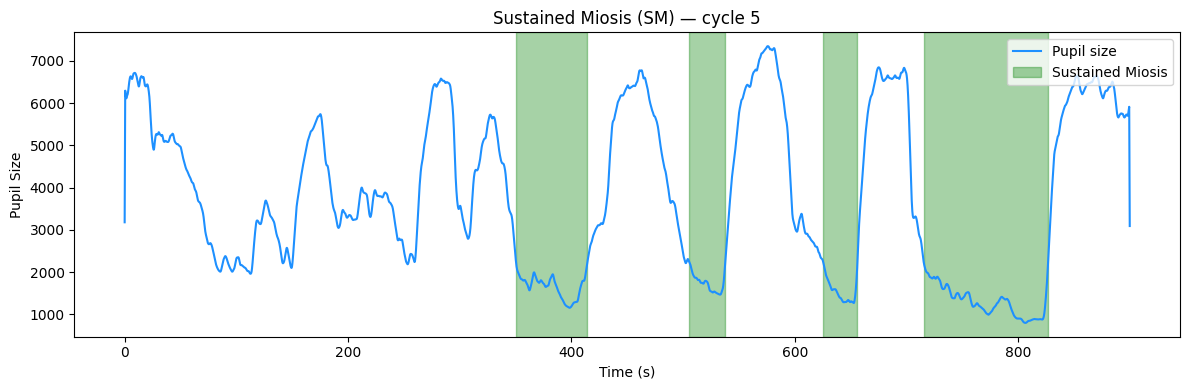

In [46]:
# Example: load datasets from folder, process first experiment, plot pupil with SM regions
datasets = load_pupil_whisker_datasets("data/raw/IP3R2_KD/2024.06.01")
if datasets:
    proc = process_dataset(datasets[4], smooth=True, smooth_sec=1.0)
    plot_pupil_with_sustained_miosis(
        proc["pupil_time"], proc["pupil_val"],
        percentile=30, min_duration_sec=30,
        title=f"Sustained Miosis (SM) — {proc['rel_path']}",
        fill_color="green", fill_alpha=0.35,
    )

### Gradual Pupillary Descent (GPD) / Sleep Onset

The 20-second window immediately preceding each SM block. Plot with filled regions (same style as SM).

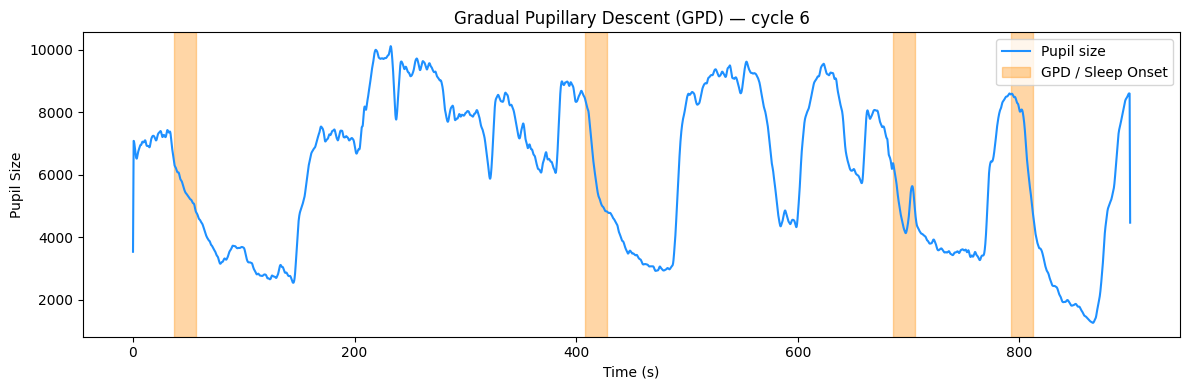

In [32]:
# Example: plot GPD (20 s before each SM block)
if datasets:
    proc = process_dataset(datasets[1], smooth=True, smooth_sec=1.0)
    plot_pupil_with_gpd(
        proc["pupil_time"], proc["pupil_val"],
        percentile=35, min_duration_sec=30, gpd_window_sec=20,
        title=f"Gradual Pupillary Descent (GPD) — {proc['rel_path']}",
        fill_color="darkorange", fill_alpha=0.35,
    )

### Active Pupillary Fluctuations (APF) / Awake

Default state: all time outside SM blocks (awake, brief dips &lt;30 s, active whisking, fidgeting). Plot with filled regions.

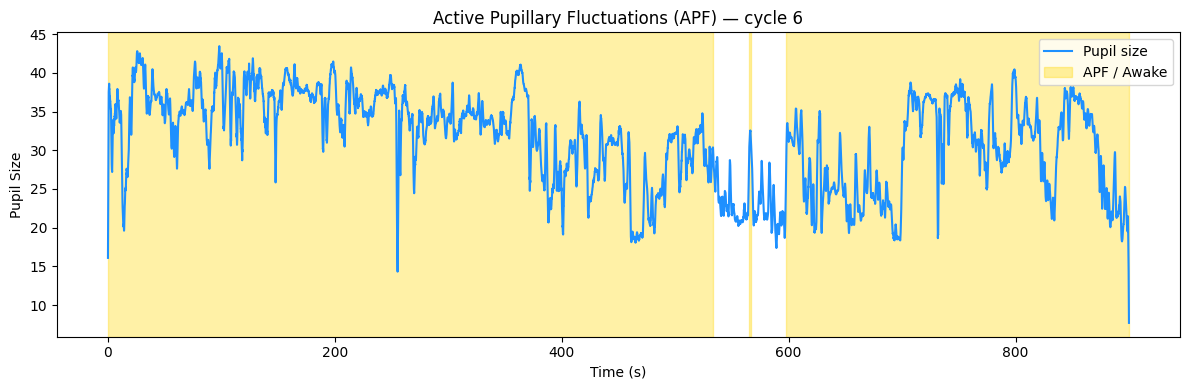

In [ ]:
# Example: plot APF (awake / non-SM segments)
if datasets:
    proc = process_dataset(datasets[1], smooth=True, smooth_sec=1.0)
    plot_pupil_with_apf(
        proc["pupil_time"], proc["pupil_val"],
        percentile=35, min_duration_sec=30,
        title=f"Active Pupillary Fluctuations (APF) — {proc['rel_path']}",
        fill_color="gold", fill_alpha=0.35,
    )

### Dynamic transition windows (signal-dependent)

SM, GPD, and RPA with **dynamic** boundaries: GPD walks backward from SM start until pupil reaches `high_threshold`; RPA walks forward from SM end until pupil recovers. No fixed 20s/5s windows.

In [56]:
# Example: dynamic classification and plot (SM, GPD, RPA)

path = "data/raw/IP3R2_KD/2024.02.18"

datasets = load_pupil_whisker_datasets(path)

if datasets:
    proc = process_dataset(datasets[2], smooth=True, smooth_sec=1.0)
    plot_pupil_with_dynamic_states(
        proc["pupil_time"], proc["pupil_val"],
        low_threshold=0.3, high_threshold=0.8, min_sm_duration=30.0,
        norm_low_percentile=1, norm_high_percentile=99,
        title=f"Dynamic states — {proc['rel_path']}\n{path}",
    )

Error reading files in data/raw/IP3R2_KD/2024.02.18/cycle 6: 'utf-8' codec can't decode byte 0xca in position 12: invalid continuation byte


IndexError: list index out of range

Error reading files in data/raw/IP3R2_KD/2024.02.18/cycle 6: 'utf-8' codec can't decode byte 0xca in position 12: invalid continuation byte


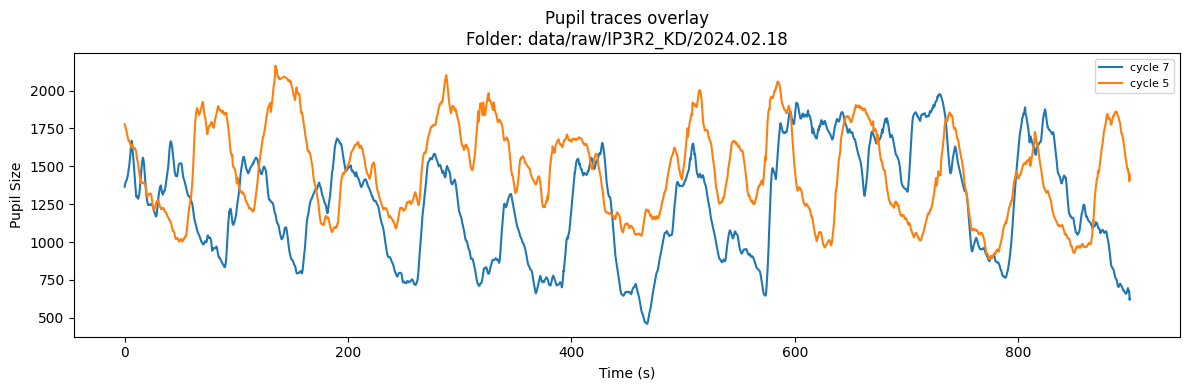

In [33]:
plot_pupil_in_folder("data/raw/IP3R2_KD/2024.02.18", overlay=True, smooth=False)

In [19]:
from scipy.signal import hilbert, medfilt, butter, filtfilt
from scipy.ndimage import gaussian_filter1d


def get_whisker_activity(df, col="whisker_gradient", sigma=40, sens=0.5):
    """
    Process raw whisker gradient into a clean activity envelope.
    Input: df (DataFrame with column `col`).
    Output: 1D np.ndarray (same length as df) for use in plotting.
    """
    clean = medfilt(df[col].values, kernel_size=5)
    baseline = np.median(clean)
    analytic_signal = hilbert(clean - baseline)
    envelope = np.abs(analytic_signal) + baseline
    thresh = baseline + (envelope.std() * sens)
    activity = np.where(envelope < thresh, baseline, envelope)
    return np.asarray(gaussian_filter1d(activity, sigma=sigma), dtype=float)


def get_arteriole_activity(df, col="arteriole_diameter", cutoff=0.025):
    """
    Process raw arteriole diameter: low-pass filter (real increase).
    Input: df (DataFrame with 'time' and column `col`).
    Output: 1D np.ndarray (same length as df) for use in plotting.
    """
    time = np.asarray(df["time"]).ravel()
    signal = np.asarray(df[col]).ravel()
    if len(time) < 2:
        return signal
    fs = 1.0 / np.mean(np.diff(time))
    b, a = butter(3, cutoff / (fs / 2), btype="low")
    real_increase = filtfilt(b, a, signal)
    return np.asarray(real_increase, dtype=float)


def plot_whisker_before_after(
    data_folder_path,
    time_window=None,
    sigma=40,
    sens=0.2,
    figsize=(14, 6),
):
    """Plot raw vs processed whisker gradient for one cycle."""
    whisker_df = load_whisker_data(data_folder_path)
    t = whisker_df["time"].values
    raw = whisker_df["whisker_gradient"].values
    processed = get_whisker_activity(whisker_df, col="whisker_gradient", sigma=sigma, sens=sens)

    if time_window is not None:
        t0, t1 = time_window
        mask = (t >= t0) & (t <= t1)
        t, raw, processed = t[mask], raw[mask], processed[mask]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    axes[0].plot(t, raw, color="grey")
    axes[0].set_ylabel("Raw")
    axes[0].set_title("Whisker gradient (raw)")

    axes[1].plot(t, processed, color="darkorange")
    axes[1].set_ylabel("Processed")
    axes[1].set_title("Whisker gradient (processed activity)")
    axes[1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()


def plot_arteriole_before_after(
    data_folder_path,
    time_window=None,
    cutoff=0.05,
    figsize=(14, 6),
):
    """Plot raw vs processed arteriole diameter for one cycle."""
    arteriole_df = load_arteriole_data(data_folder_path)
    t = arteriole_df["time"].values
    raw = arteriole_df["arteriole_diameter"].values
    processed = get_arteriole_activity(arteriole_df, col="arteriole_diameter", cutoff=cutoff)

    if time_window is not None:
        t0, t1 = time_window
        mask = (t >= t0) & (t <= t1)
        t, raw, processed = t[mask], raw[mask], processed[mask]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    axes[0].plot(t, raw, color="grey")
    axes[0].set_ylabel("Raw")
    axes[0].set_title("Arteriole diameter (raw)")

    axes[1].plot(t, processed, color="crimson")
    axes[1].set_ylabel("Processed")
    axes[1].set_title("Arteriole diameter (processed activity)")
    axes[1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

import os
import numpy as np
from src.data.data_loader import (
    load_pupil_data,
    load_whisker_data,
    load_arteriole_data,
    load_calcium_data,
)

import matplotlib.pyplot as plt


def load_multimodal_traces(data_folder_path):
    """Load pupil, whisker_gradient, arteriole_diameter, and calcium from one folder.

    Returns a dict of DataFrames keyed by signal name.
    """
    pupil_df = load_pupil_data(data_folder_path)
    whisker_df = load_whisker_data(data_folder_path)
    arteriole_df = load_arteriole_data(data_folder_path)
    calcium_df = load_calcium_data(data_folder_path)
    return {
        "pupil": pupil_df,          # columns: time, pupil_size
        "whisker": whisker_df,      # columns: whisker_gradient, time
        "arteriole": arteriole_df,  # columns: time, arteriole_diameter
        "calcium": calcium_df,      # columns: time, calcium
    }


def plot_multimodal_traces(
    data_folder_path,
    time_window=None,
    figsize=(14, 8),
    normalize_mode="day",  # "day" or "cycle"
    low_percentile=1.0,
    high_percentile=99.0,
    process_whisker=False,
    process_arteriole=False,
):
    """Visualize normalized whisker_gradient, arteriole_diameter, calcium, and pupil_size.

    Normalization modes:
    - "day": All signals use percentiles computed across the entire day (parent folder).
    - "cycle": All signals use percentiles computed from the current cycle only.

    Percentiles:
    - low_percentile / high_percentile control the min/max of the normalization range
      (e.g. 1 and 99, or 0.5 and 99.5, or 0.05 and 99.95).

    Args:
        data_folder_path: Path to folder with arteriole, calcium, pupil, and whisker CSVs.
        time_window: Optional (t_start, t_end) in seconds to zoom into a window.
        figsize: Figure size.
        normalize_mode: "day" or "cycle".
        low_percentile: Lower percentile for normalization (float in [0, 50)).
        high_percentile: Upper percentile for normalization (float in (50, 100]).
    """
    data = load_multimodal_traces(data_folder_path)

    # Compute percentiles for pupil, arteriole, calcium
    day_folder = os.path.dirname(os.path.normpath(data_folder_path))
    pupil_vals, art_vals, ca_vals = [], [], []
    if normalize_mode == "day" and os.path.isdir(day_folder):
        for name in os.listdir(day_folder):
            sub = os.path.join(day_folder, name)
            if not os.path.isdir(sub):
                continue
            try:
                df_p = load_pupil_data(sub)
                pupil_vals.append(df_p["pupil_size"].values)
            except Exception:
                pass
            try:
                df_a = load_arteriole_data(sub)
                art_vals.append(df_a["arteriole_diameter"].values)
            except Exception:
                pass
            try:
                df_c = load_calcium_data(sub)
                ca_vals.append(df_c["calcium"].values)
            except Exception:
                pass

    def _percentiles_from(list_of_arrays):
        if not list_of_arrays:
            return None, None
        arr = np.concatenate(list_of_arrays)
        lo = np.nanpercentile(arr, low_percentile)
        hi = np.nanpercentile(arr, high_percentile)
        return lo, hi


    def _normalize(y, lo, hi):
        if lo is None or hi is None or hi <= lo:
            return y
        return np.clip((y - lo) / (hi - lo), 0, 1)

    # For cycle mode, build percentiles from this cycle only
    if normalize_mode == "cycle":
        pupil_vals = [data["pupil"]["pupil_size"].values]
        art_vals = [data["arteriole"]["arteriole_diameter"].values]
        ca_vals = [data["calcium"]["calcium"].values]

    p_lo, p_hi = _percentiles_from(pupil_vals)
    art_lo, art_hi = _percentiles_from(art_vals)
    ca_lo, ca_hi = _percentiles_from(ca_vals)

    data = load_multimodal_traces(data_folder_path)

    pupil = data["pupil"]
    whisker = data["whisker"]
    arteriole = data["arteriole"]
    calcium = data["calcium"]

    pupil_t, pupil_y = pupil["time"].values, pupil["pupil_size"].values
    whisker_t, whisker_y = whisker["time"].values, whisker["whisker_gradient"].values
    art_t, art_y = arteriole["time"].values, arteriole["arteriole_diameter"].values
    ca_t, ca_y = calcium["time"].values, calcium["calcium"].values

    # Optional processing of whisker and arteriole traces before normalization
    if process_whisker:
        try:
            whisker_y = get_whisker_activity(whisker, col="whisker_gradient")
        except Exception:
            pass
    if process_arteriole:
        try:
            art_y = get_arteriole_activity(arteriole, col="arteriole_diameter")
        except Exception:
            pass

    # Whisker: same normalization scheme as other signals (per day or per cycle)
    if normalize_mode == "day":
        # For day mode, include whisker from all cycles in the day
        whisker_vals = []
        if os.path.isdir(day_folder):
            for name in os.listdir(day_folder):
                sub = os.path.join(day_folder, name)
                if not os.path.isdir(sub):
                    continue
                try:
                    df_w = load_whisker_data(sub)
                    whisker_vals.append(df_w["whisker_gradient"].values)
                except Exception:
                    pass
        w_lo, w_hi = _percentiles_from(whisker_vals)
    else:  # cycle mode
        if len(whisker_y) > 0:
            w_lo = np.nanpercentile(whisker_y, low_percentile)
            w_hi = np.nanpercentile(whisker_y, high_percentile)
        else:
            w_lo = w_hi = None

    pupil_y = _normalize(pupil_y, p_lo, p_hi)
    art_y = _normalize(art_y, art_lo, art_hi)
    ca_y = _normalize(ca_y, ca_lo, ca_hi)
    whisker_y = _normalize(whisker_y, w_lo, w_hi)

    if time_window is not None:
        t0, t1 = time_window
        pupil_mask = (pupil_t >= t0) & (pupil_t <= t1)
        whisker_mask = (whisker_t >= t0) & (whisker_t <= t1)
        art_mask = (art_t >= t0) & (art_t <= t1)
        ca_mask = (ca_t >= t0) & (ca_t <= t1)
        pupil_t, pupil_y = pupil_t[pupil_mask], pupil_y[pupil_mask]
        whisker_t, whisker_y = whisker_t[whisker_mask], whisker_y[whisker_mask]
        art_t, art_y = art_t[art_mask], art_y[art_mask]
        ca_t, ca_y = ca_t[ca_mask], ca_y[ca_mask]

    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)

    axes[0].plot(pupil_t, pupil_y, color="dodgerblue")
    axes[0].set_ylabel("Pupil (norm)")
    axes[0].set_title("Pupil size" + (" (day-normalized)" if normalize_mode == "day" else " (cycle-normalized)"))
    axes[0].set_ylim(0, 1)

    axes[1].plot(whisker_t, whisker_y, color="darkorange")
    axes[1].set_ylabel("Whisker (norm)")
    axes[1].set_title("Whisker gradient" + (" (day-normalized)" if normalize_mode == "day" else " (cycle-normalized)"))
    axes[1].set_ylim(0, 1)

    axes[2].plot(art_t, art_y, color="crimson")
    axes[2].set_ylabel("Arteriole (norm)")
    axes[2].set_title("Arteriole diameter" + (" (day-normalized)" if normalize_mode == "day" else " (cycle-normalized)"))
    axes[2].set_ylim(0, 1)

    axes[3].plot(ca_t, ca_y, color="seagreen")
    axes[3].set_ylabel("Calcium (norm)")
    axes[3].set_title("Calcium" + (" (day-normalized)" if normalize_mode == "day" else " (cycle-normalized)"))
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylim(0, 1)

    fig.suptitle(f"Multimodal normalized traces: {data_folder_path}", y=1.02)
    plt.tight_layout()
    plt.show()


# Example usage:
# plot_multimodal_traces("data/raw/IP3R2_KD/2023.08.25/cycle 5")


Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/6_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/6_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/calcium.csv


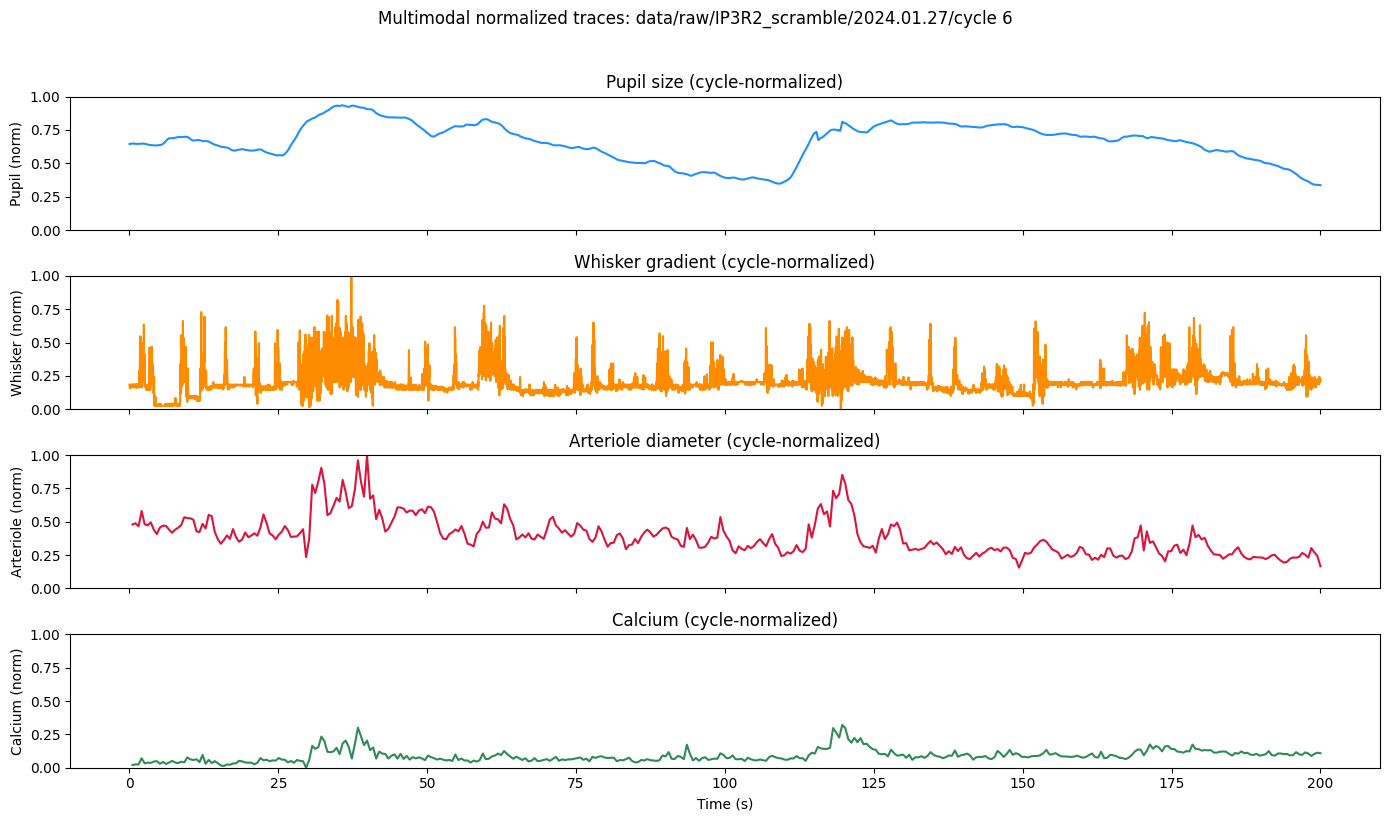

In [21]:
plot_multimodal_traces(
    "data/raw/IP3R2_scramble/2024.01.27/cycle 6",
    normalize_mode="cycle",
    time_window=(0, 200),
    low_percentile=0,
    high_percentile=100,
    process_whisker=False,
    process_arteriole=False,
)



Loading arteriole data from: data/raw/IP3R2_KD/2023.08.25/cycle 5/arteriole_diameter.csv


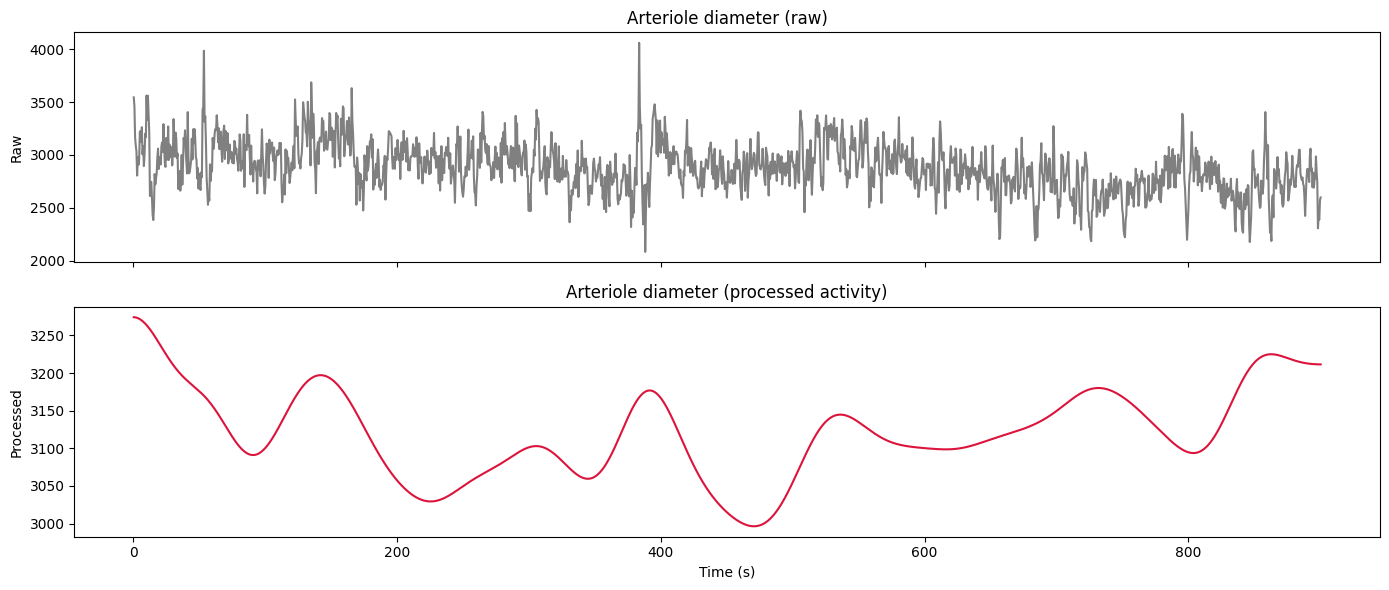

In [60]:
plot_arteriole_before_after("data/raw/IP3R2_KD/2023.08.25/cycle 5")

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/6_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/6_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/calcium.csv


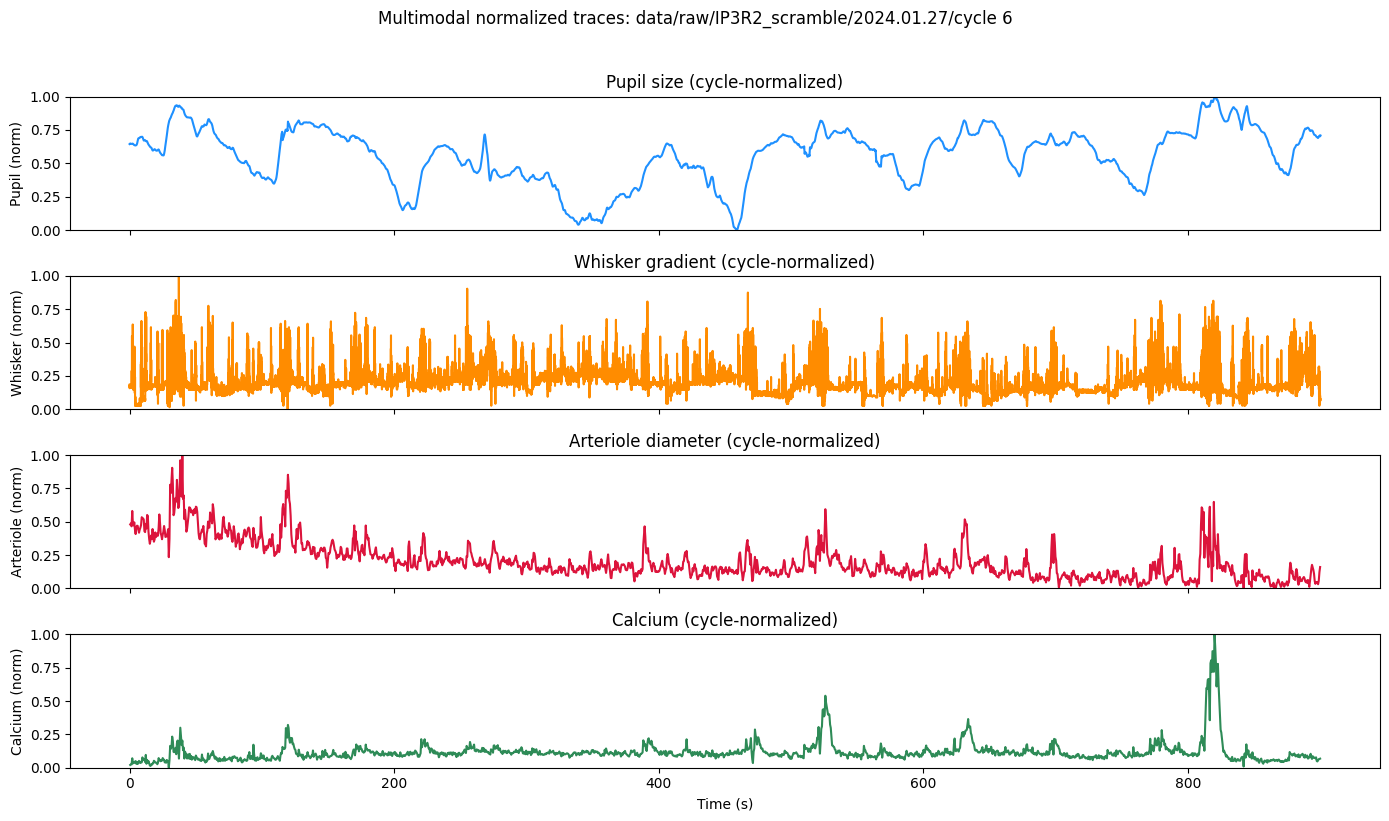

In [48]:
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 6", time_window=(0, 900), normalize_mode="cycle", low_percentile=0, high_percentile=100)

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/7_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2

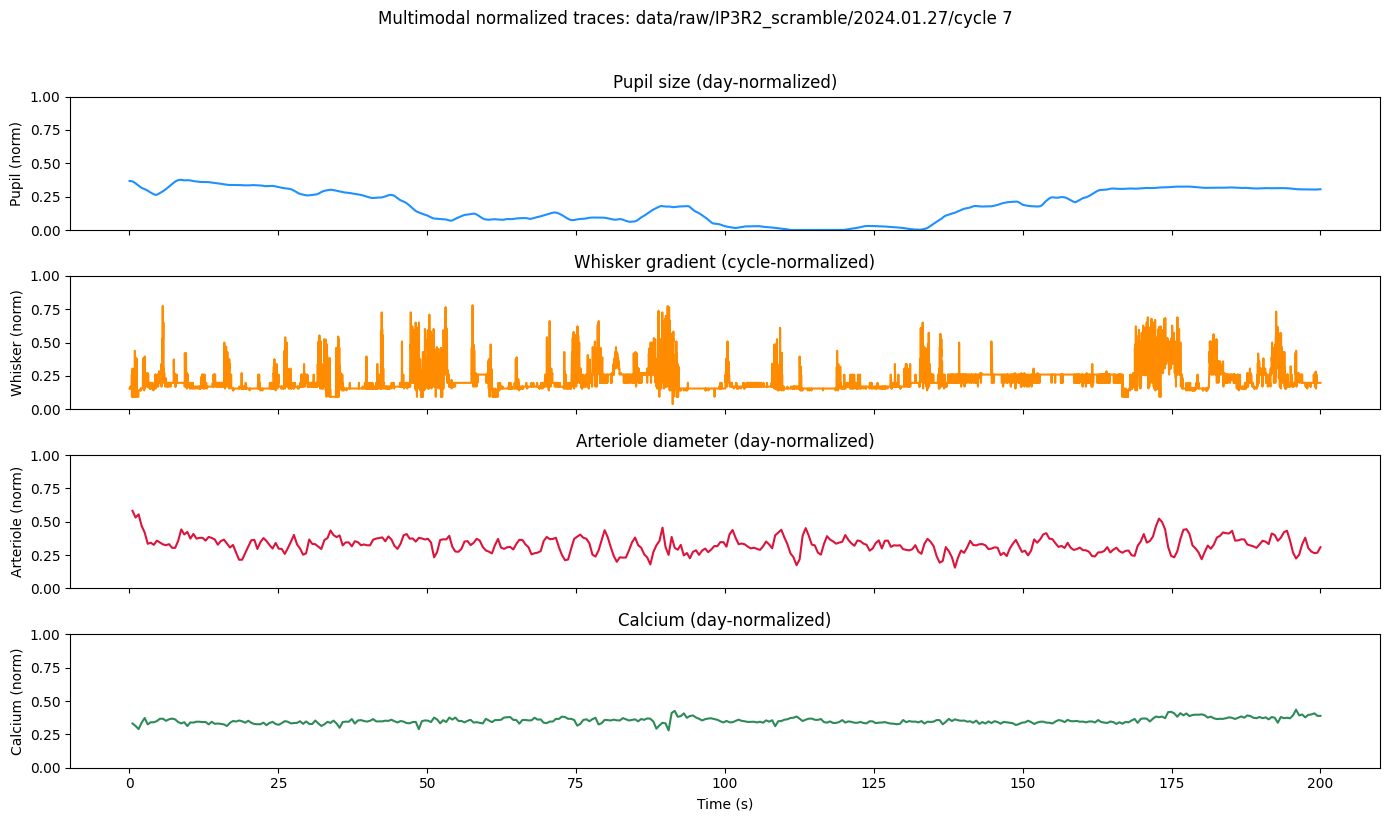

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/7_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2

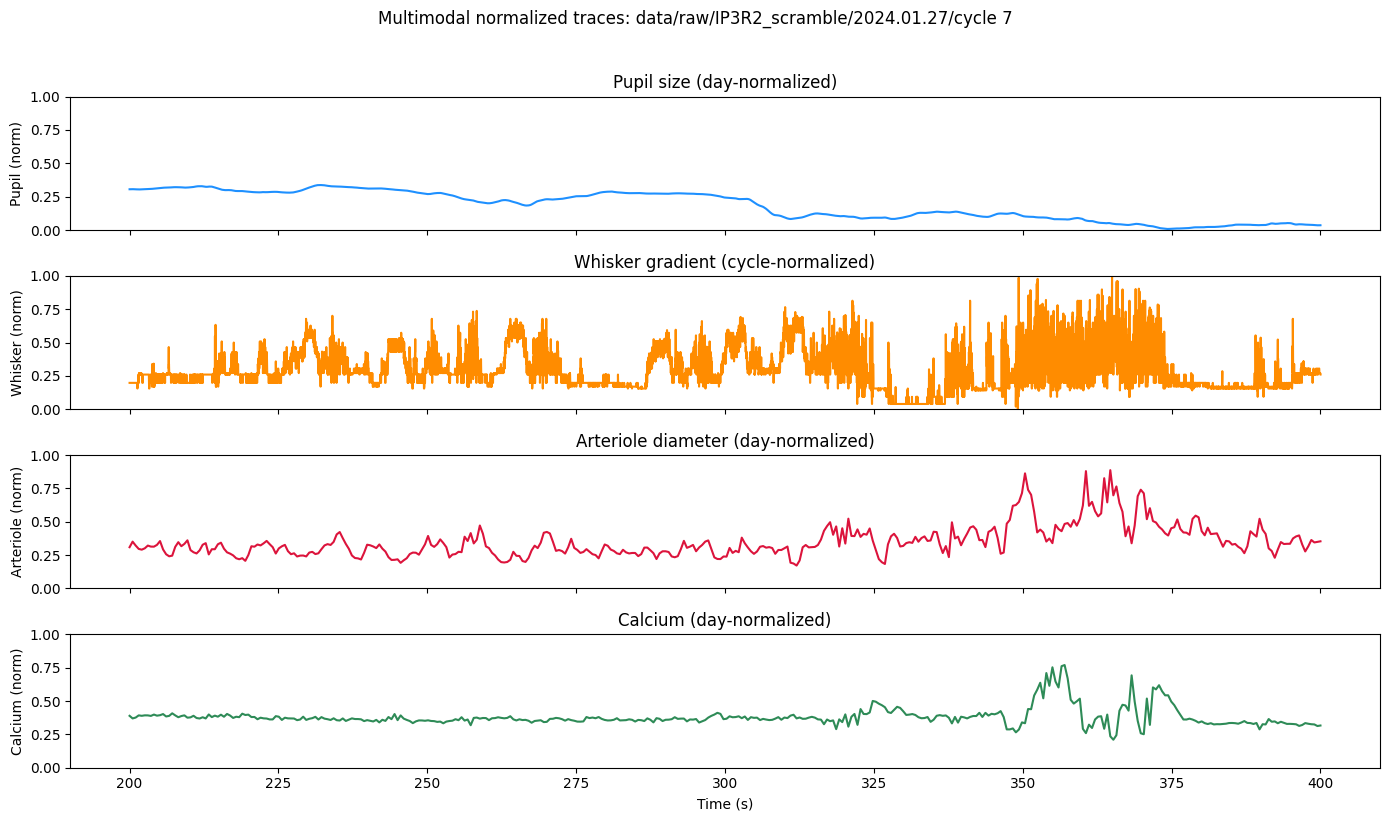

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/7_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2

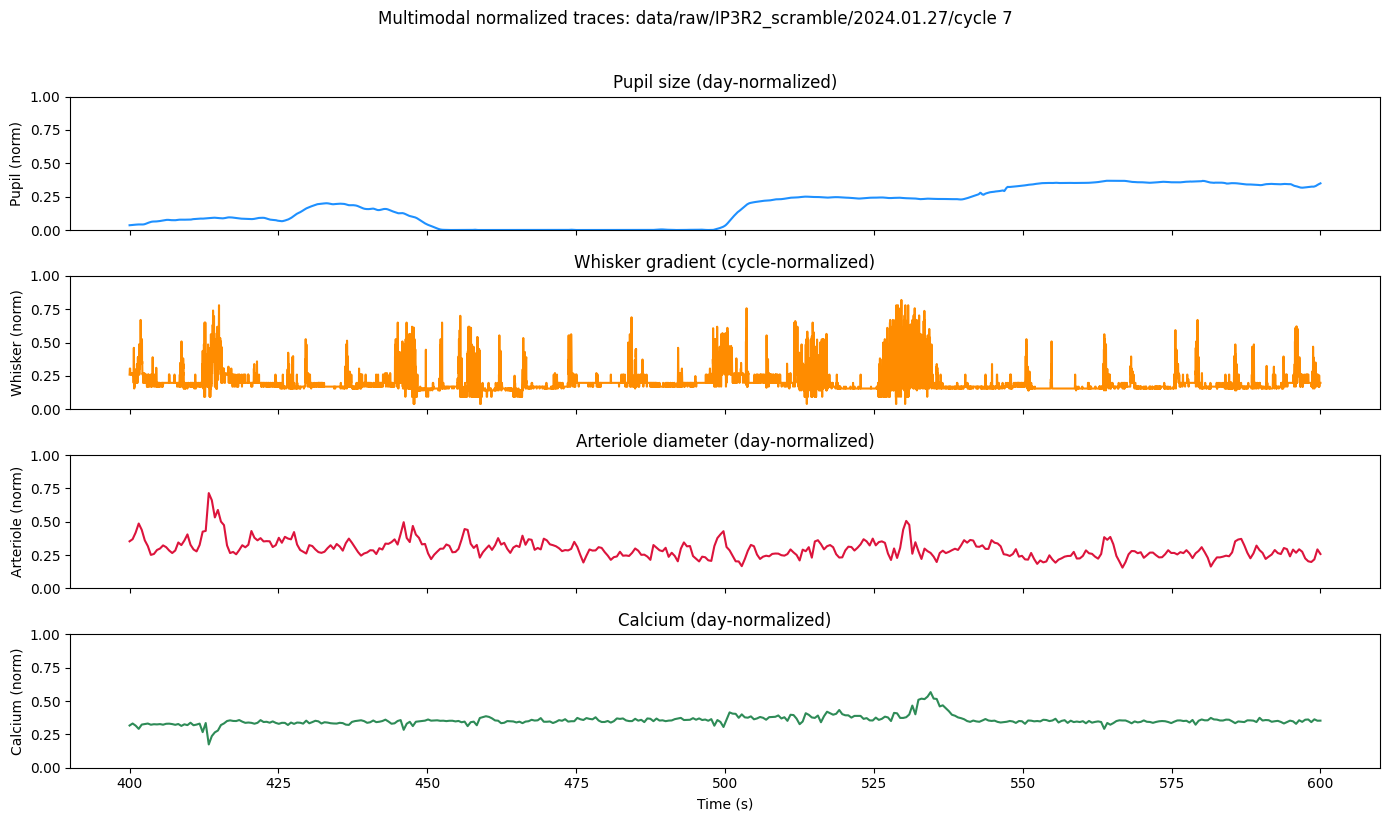

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/7_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2

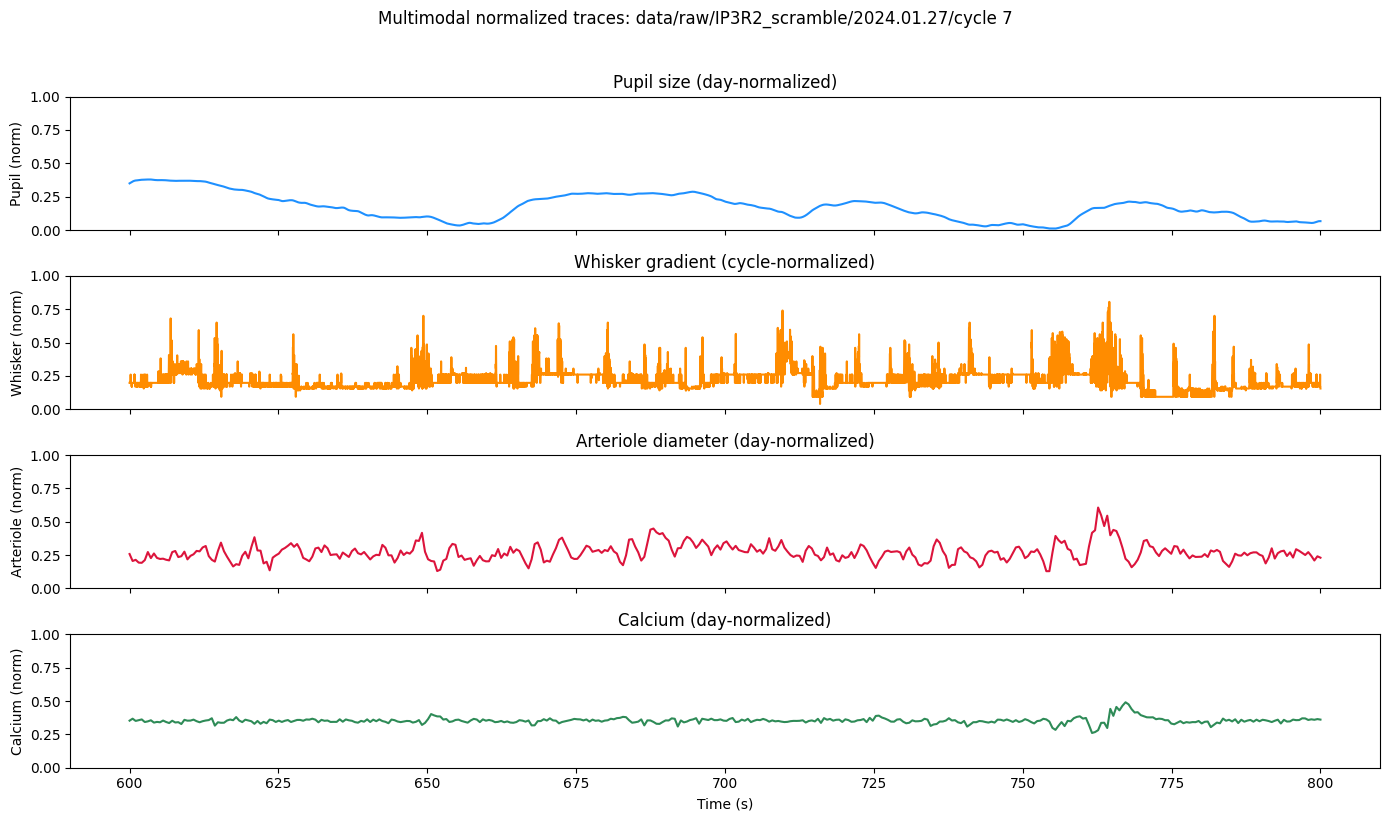

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/7_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 9/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 7/calcium.csv
Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 6/pupil_size.csv
Loading arteriole data from: data/raw/IP3R2

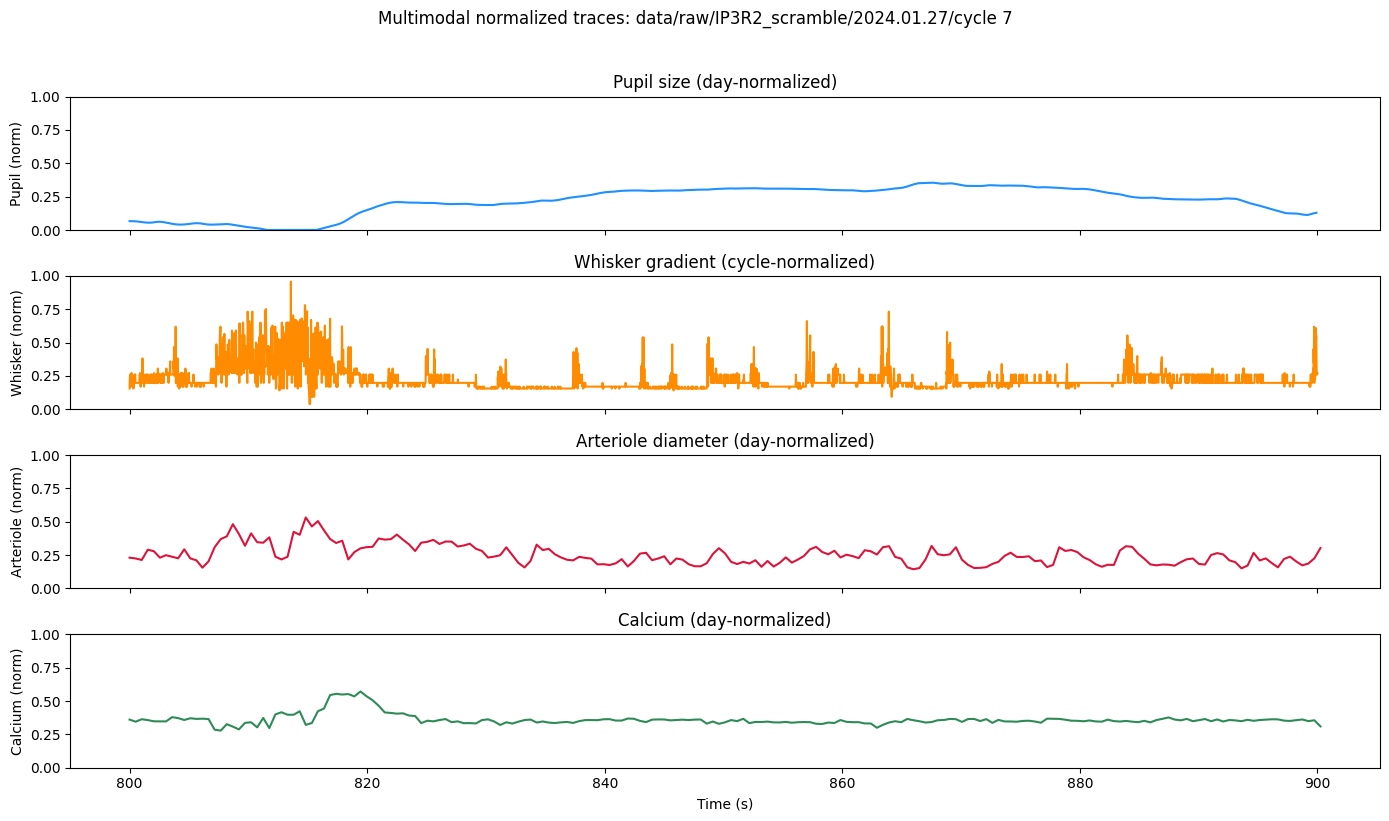

In [28]:
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 7", time_window=(00, 200))
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 7", time_window=(200, 400))
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 7", time_window=(400, 600))
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 7", time_window=(600, 800))
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 7", time_window=(800, 1000))

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/8_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/calcium.csv


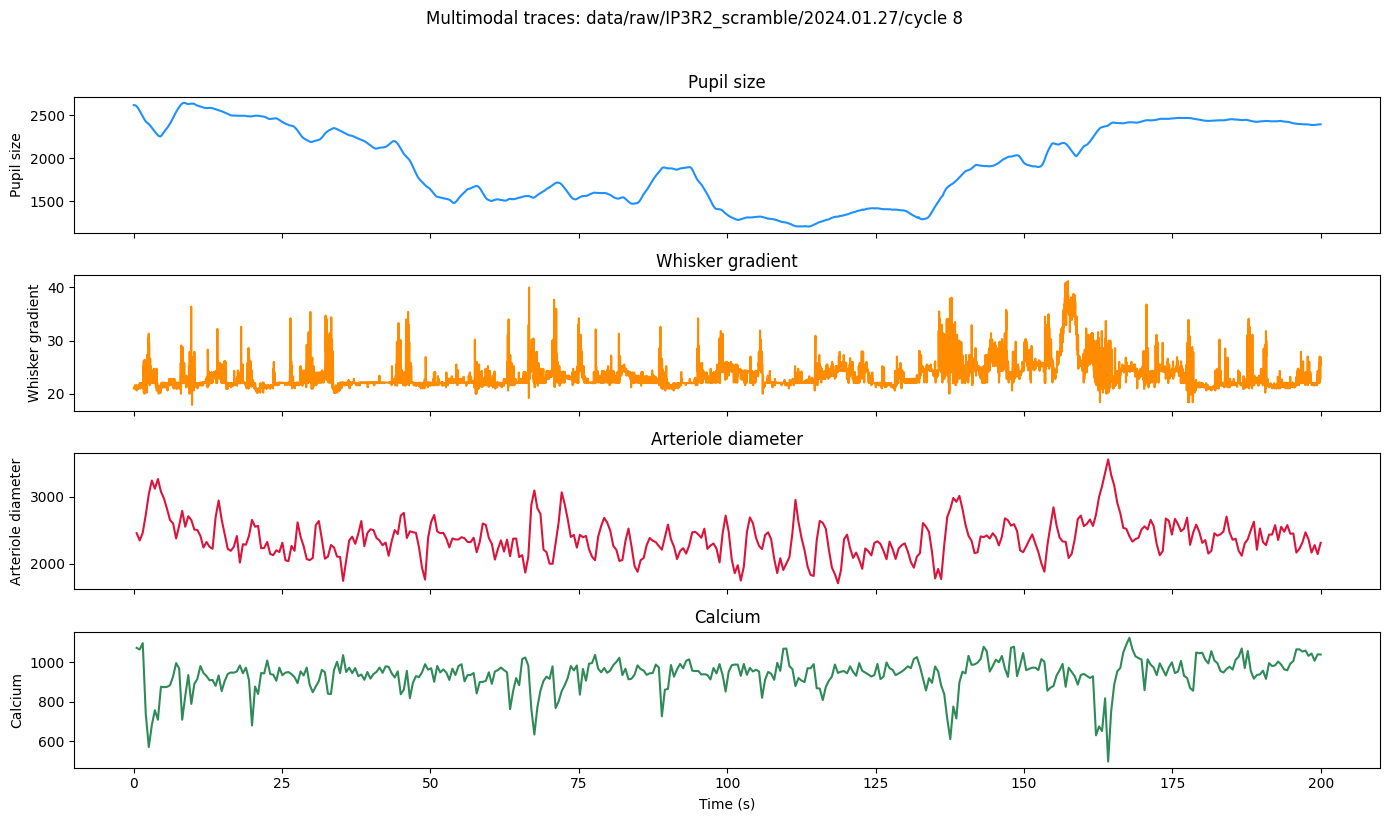

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/8_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/calcium.csv


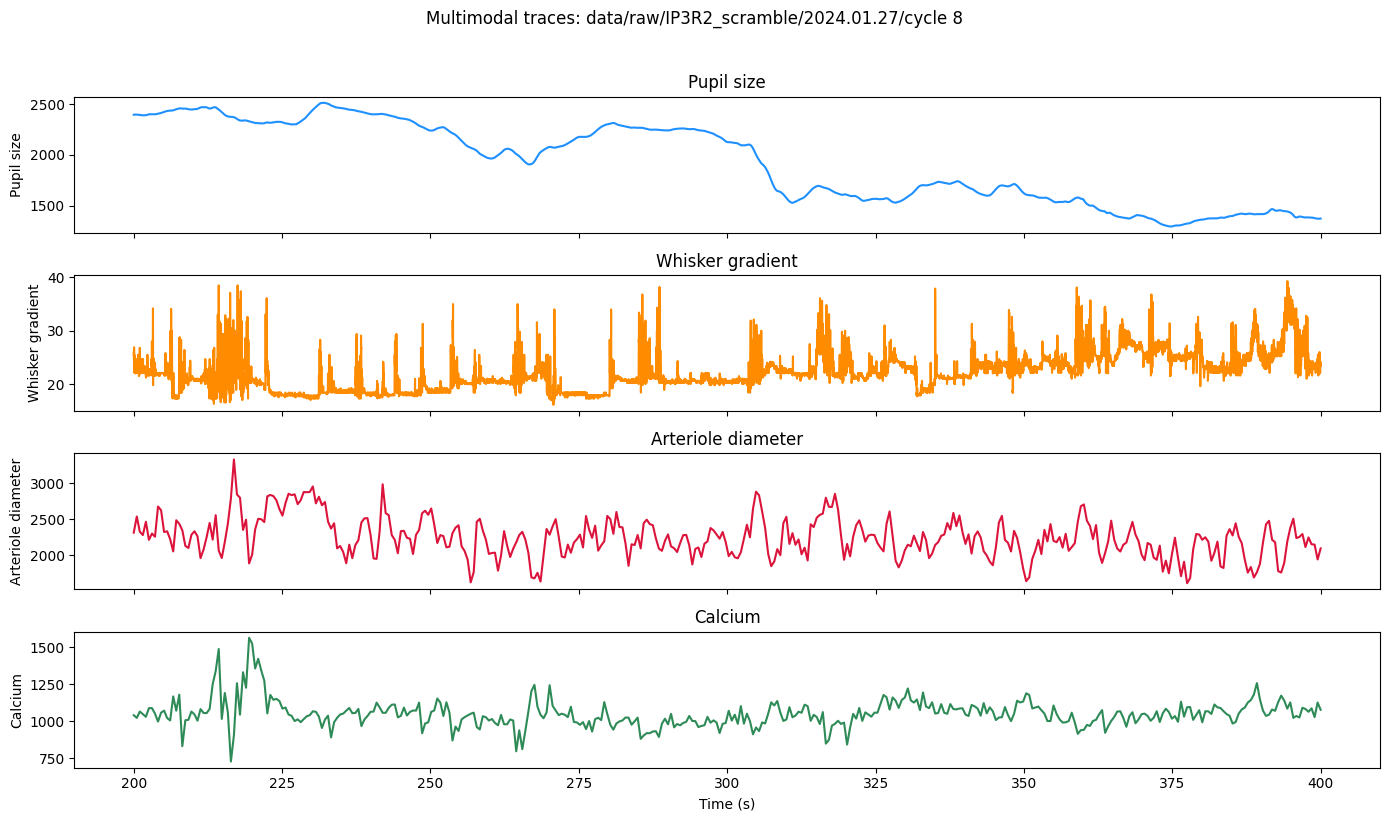

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/8_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/calcium.csv


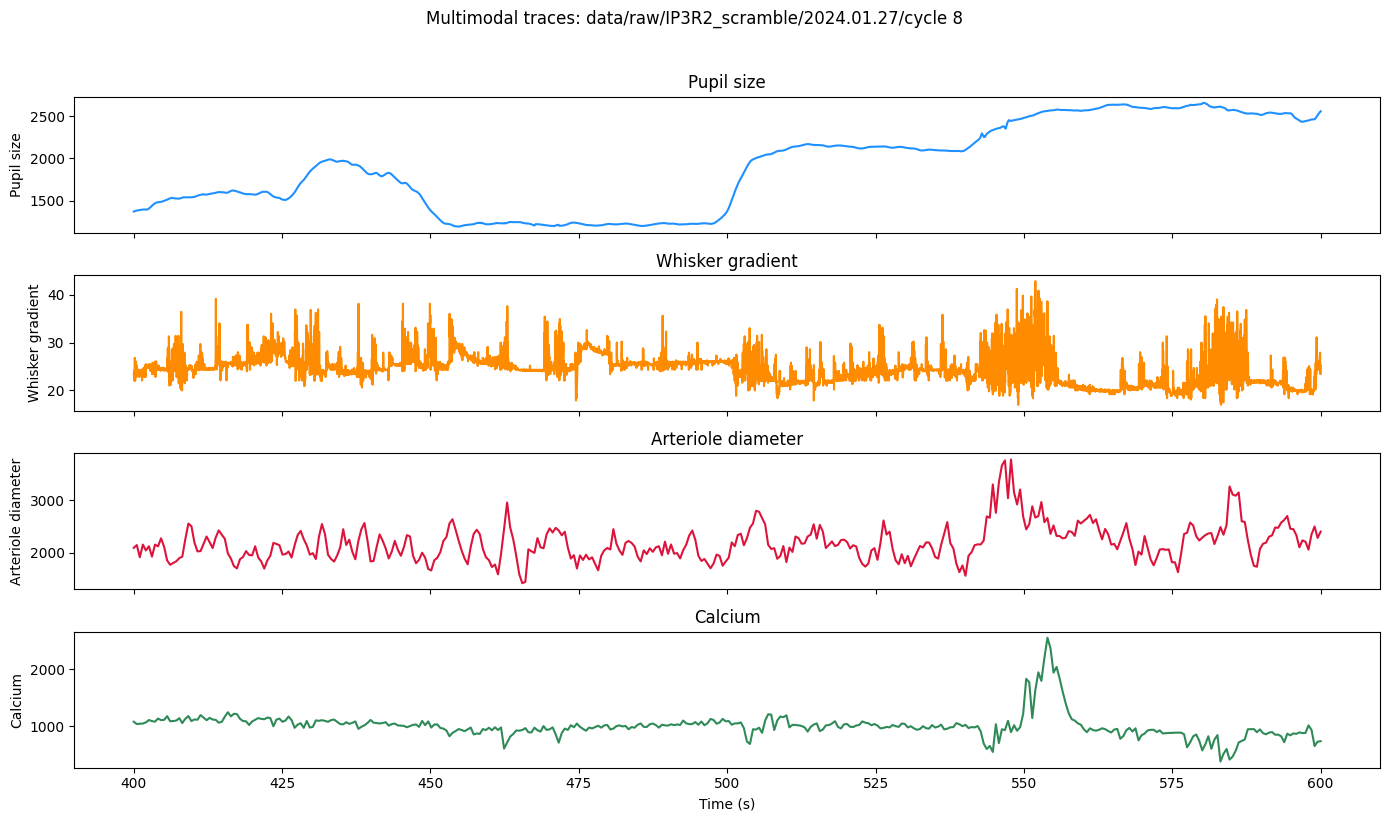

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/8_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/calcium.csv


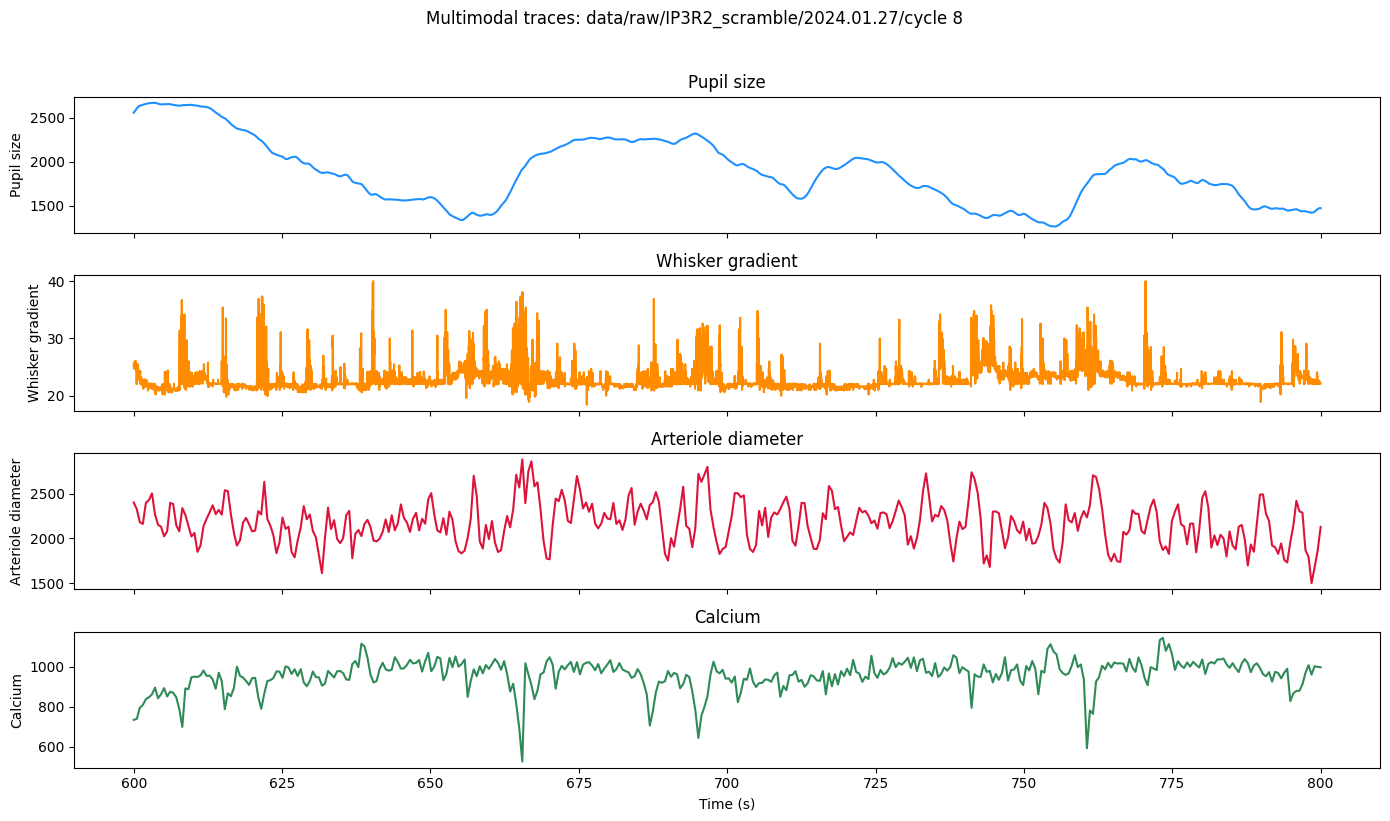

Loading pupil data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/pupil_size.csv
Loading whisker data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/8_whisker_gradients.csv
Loading arteriole data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/arteriole_diameter.csv
Loading calcium data from: data/raw/IP3R2_scramble/2024.01.27/cycle 8/calcium.csv


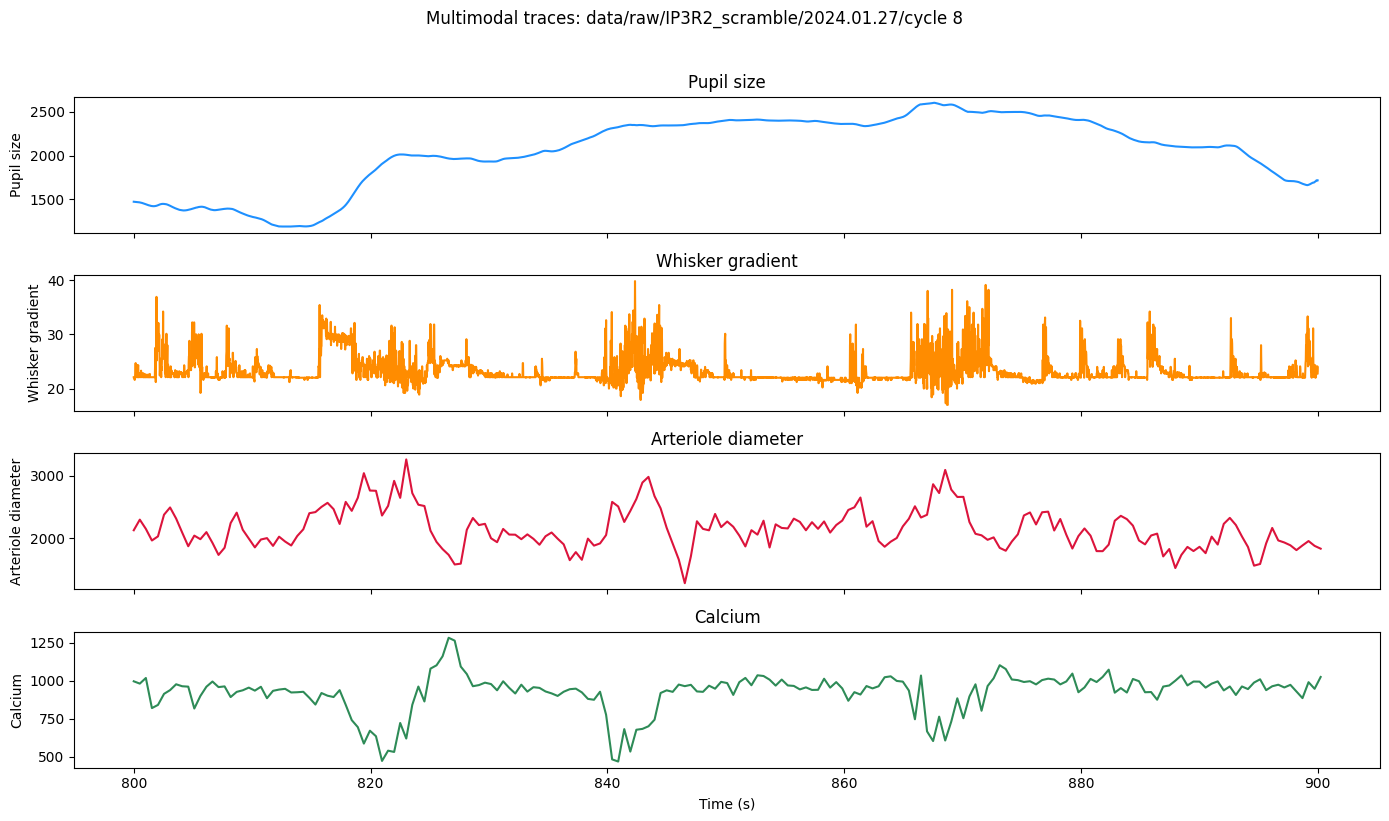

In [ ]:
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 8", time_window=(00, 200))
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 8", time_window=(200, 400))
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 8", time_window=(400, 600))
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 8", time_window=(600, 800))
plot_multimodal_traces("data/raw/IP3R2_scramble/2024.01.27/cycle 8", time_window=(800, 1000))

### Whisker and Arteriole processing

In [5]:
import pandas as pd
import numpy as np
import glob
import os
from scipy.ndimage import gaussian_filter1d

def standardize_by_mouse_day(folder, pattern="IP3R2_scramble_*_pupil.csv"):
    # Find all files in the specified folder matching the pattern
    search_pattern = os.path.join(folder, pattern)
    all_files = sorted(glob.glob(search_pattern))
    groups = {}
    for f in all_files:
        prefix = "_".join(f.split("_")[:3])
        groups.setdefault(prefix, []).append(f)
        
    final_output = []
    
    for prefix, p_files in groups.items():
        daily_p_signals = []
        
        # --- Step 1: Individual Cycle Pre-Processing ---
        for pf in p_files:
            df_p = pd.read_csv(pf, encoding="utf-8", encoding_errors="replace")
            
            # Pupil: Clean and Detrend Phasic Signal
            p_val = df_p.iloc[:,1].values.astype(float)
            p_val[p_val <= 0] = np.nan
            p_clean = pd.Series(p_val).interpolate(limit_direction='both').ffill().bfill().values
            p_smooth = gaussian_filter1d(p_clean, sigma=25)
            
            # Detrend per cycle to remove tonic drift
            window = int(60 / np.mean(np.diff(df_p.iloc[:,0].values)))
            baseline = pd.Series(p_smooth).rolling(window=window, center=True, min_periods=1).quantile(0.1).values
            p_phasic = p_smooth - baseline
            
            daily_p_signals.append(p_phasic)
            
        # --- Step 2: Global Mouse-Day Standardization ---
        # Calculate stats across ALL cycles for this mouse today
        p_concat = np.concatenate(daily_p_signals)
        p_mu, p_std = np.mean(p_concat), np.std(p_concat)
        
        # Apply the global stats back to each individual cycle
        for i, pf in enumerate(p_files):
            p_z = (daily_p_signals[i] - p_mu) / (p_std + 1e-9)
            
            final_output.append({
                'session_id': pf.replace("_pupil.csv", ""),
                'pupil_z': p_z
            })
            
    return final_output

In [6]:
final_output = standardize_by_mouse_day(folder="/Users/giahuyhoangle/Projects/PupilBasedWakingUpEventDetection/PupilBasedWakingUpEventDetection/data/pupil_whisker")

In [7]:
final_output

# loop through the final_output and plot the pupil_z in different subplots and different colors the session_id now should be last part of the file name

for item in final_output:
    plt.plot(item['pupil_z'], label=item['session_id'].split("/")[-1])





In [15]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import medfilt

def standardize_and_save_by_mouse_day(folder, pattern="IP3R2_*_pupil.csv", max_time=900, noise_threshold=0.02, plot_diagnostics=True):
    search_pattern = os.path.join(folder, pattern)
    all_files = sorted(glob.glob(search_pattern))
    groups = {}
    
    for f in all_files:
        fname = os.path.basename(f)
        prefix = "_".join(fname.split("_")[:3])
        groups.setdefault(prefix, []).append(f)
        
    final_output = []
    
    for prefix, p_files in groups.items():
        daily_p_data = [] 
        
        for pf in p_files:
            df_p = pd.read_csv(pf, encoding="utf-8", encoding_errors="replace")

            # Excel junk cleanup
            tcol, vcol = df_p.columns[0], df_p.columns[1]
            df_p[tcol] = pd.to_numeric(df_p[tcol], errors="coerce")
            df_p[vcol] = pd.to_numeric(df_p[vcol], errors="coerce")
            df_p = df_p.dropna(subset=[tcol]).sort_values(tcol)
            df_p = df_p[df_p[tcol] <= max_time].reset_index(drop=True)

            times = df_p.iloc[:,0].values
            p_val = df_p.iloc[:,1].values.astype(float)
            
            # 1. Initial Cleaning
            p_val[p_val <= 0] = np.nan
            p_clean = pd.Series(p_val).interpolate(limit_direction='both').ffill().bfill().values
            
            # 2. Noise Check
            y_range = (np.nanmax(p_clean) - np.nanmin(p_clean)) + 1e-9
            y_norm = (p_clean - np.nanmin(p_clean)) / y_range
            y_check_smooth = gaussian_filter1d(y_norm, sigma=25)
            noise_score = np.std(y_norm - y_check_smooth)
            
            # 3. DYNAMIC ADAPTIVE SMOOTHING
            dt = np.diff(times)
            dt = dt[np.isfinite(dt) & (dt > 0)]
            fs = (1.0 / np.mean(dt)) if len(dt) else 50.0
            
            if noise_score > noise_threshold:
                # --- DYNAMIC WINDOW CALCULATION ---
                # Example: for score 0.05, k_sec = 0.5 + (0.05 * 20) = 1.5s
                # For score 0.10, k_sec = 0.5 + (0.10 * 20) = 2.5s
                k_sec = 0.5 + (noise_score * 20) 
                k_sec = min(k_sec, 2.5) # Cap at 2.5s to preserve real events
                
                k_size = int(k_sec * fs) 
                if k_size % 2 == 0: k_size += 1
                
                p_filtered = medfilt(p_clean, kernel_size=k_size)
                # Scale Gaussian sigma with the noise as well
                dynamic_sigma = 25 * (1 + noise_score * 10)
                p_smooth = gaussian_filter1d(p_filtered, sigma=dynamic_sigma)
                method = f"Adaptive (Med {k_sec:.1f}s | Sigma {dynamic_sigma:.1f})"
            else:
                p_smooth = gaussian_filter1d(p_clean, sigma=25)
                method = "Standard"

            # 4. Detrending
            window_size = int(60 * fs)
            baseline = pd.Series(p_smooth).rolling(window=window_size, center=True, min_periods=1).quantile(0.1).values
            p_phasic = p_smooth - baseline
            daily_p_data.append((times, p_phasic, p_clean, p_smooth, noise_score, method))

            if plot_diagnostics:
                plt.figure(figsize=(10, 4))
                plt.plot(times, p_clean, color='gray', alpha=0.3, label='Raw')
                plt.plot(times, p_smooth, color='blue', label=method)
                plt.title(f"{os.path.basename(pf)} | Noise: {noise_score:.4f}")
                plt.legend()
                plt.savefig(pf.replace(".csv", "_diagnostic.png"))
                plt.close()
            
        # --- Step 2 & 3: Standardization and Saving ---
        p_concat = np.concatenate([data[1] for data in daily_p_data])
        p_mu, p_std = np.nanmean(p_concat), np.nanstd(p_concat)
        
        for i, pf in enumerate(p_files):
            times_i, phasic_i, _, _, score_i, meth_i = daily_p_data[i]
            p_z = (phasic_i - p_mu) / (p_std + 1e-9)
            
            out_df = pd.DataFrame({'time': times_i, 'pupil_z': p_z})
            out_path = pf.replace(".csv", "_standardized.csv")
            out_df.to_csv(out_path, index=False)
            
            final_output.append({
                'session_id': os.path.basename(pf).replace(".csv", ""),
                'noise_score': score_i,
                'method': meth_i,
                'saved_file': out_path
            })
            
    return final_output

# Execution example:
results = standardize_and_save_by_mouse_day(
    "data/pupil_whisker_arteriole",
    pattern="IP3R2_KD_*_pupil.csv",
    max_time=900,
    noise_threshold=0.01,
)

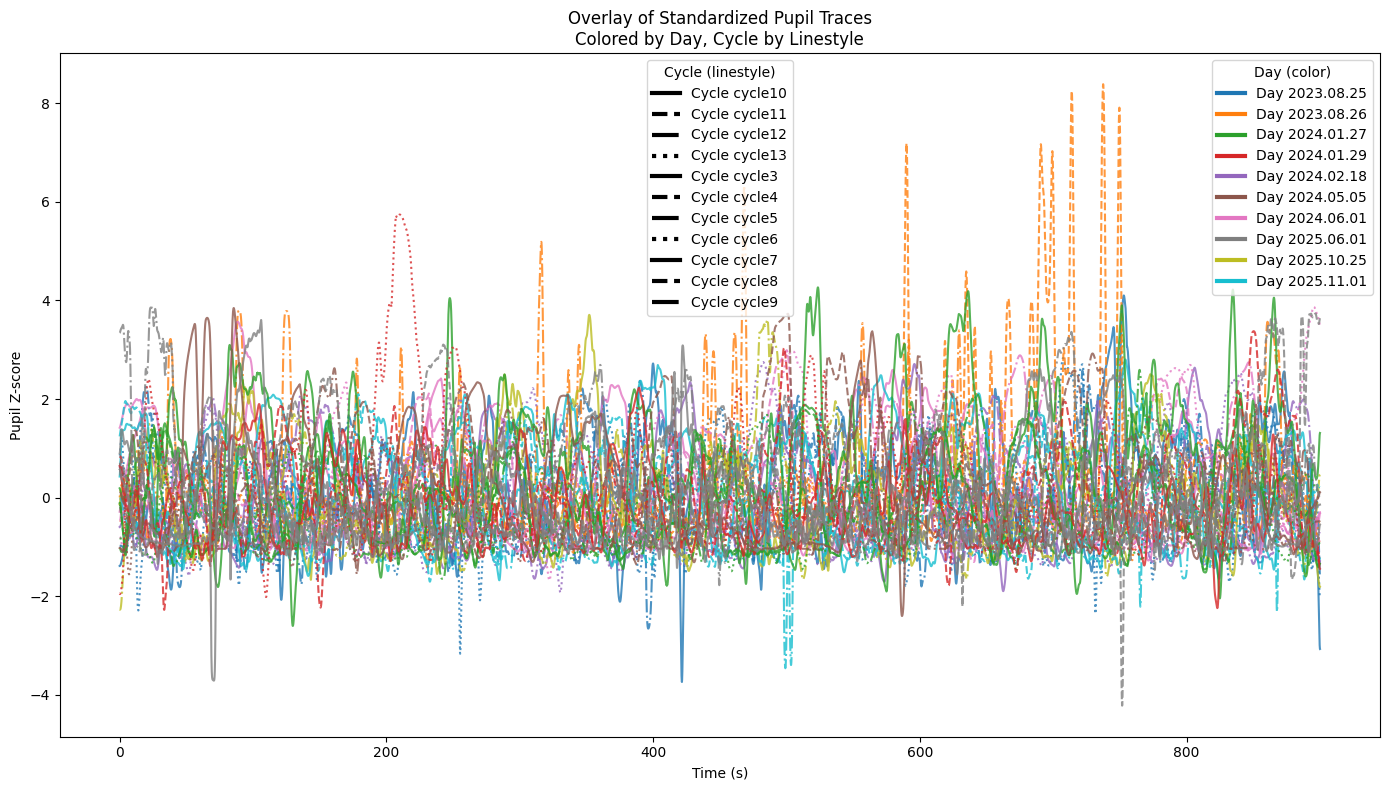

In [17]:
#load all csv file in the data/pupil_whisker_arteriole folder, read file starts with IP3R2_scramble_*_pupil_standardized.csv, and plot the pupil_z in different subplots and different colors the session_id now should be last part of the file name and ends with _pupil_standardized.csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d
import os

# Plot overlay, legend by day and cycle (split by '_' index 2 for day, 3 for cycle)
import glob

data_folder = "data/pupil_whisker_arteriole"
pattern = os.path.join(data_folder, "IP3R2_*_*_pupil_standardized.csv")
csv_files = sorted(glob.glob(pattern))

# Collect per file: day, cycle, pupil_z, time
sessions = []
for filepath in csv_files:
    filename = os.path.basename(filepath)
    parts = filename.replace("_pupil_standardized.csv", "").split('_')
    # Expecting something like: IP3R2_scramble_X_Y_Z..., take parts[2]: day, parts[3]: cycle
    day = parts[2] if len(parts) > 2 else "unknown"
    cycle = parts[3] if len(parts) > 3 else "unknown"
    df = pd.read_csv(filepath)
    if 'pupil_z' in df.columns and 'time' in df.columns:
        sessions.append({
            "day": day,
            "cycle": cycle,
            "pupil_z": df["pupil_z"].values,
            "time": df["time"].values,
            "session_id": "_".join(parts),
        })

# Make overlay plot: color by day, linestyle by cycle
fig, ax = plt.subplots(figsize=(14, 8))
import itertools

days = list(sorted({s['day'] for s in sessions}))
cycles = list(sorted({s['cycle'] for s in sessions}))
color_map = dict(zip(days, plt.cm.tab10.colors[:len(days)]))
linestyles = ['-', '--', '-.', ':']
cycle_styles = dict(zip(cycles, itertools.cycle(linestyles)))

for s in sessions:
    color = color_map.get(s['day'], 'gray')
    ls = cycle_styles.get(s['cycle'], '-')
    label = f"Day {s['day']} - Cycle {s['cycle']}"
    ax.plot(s['time'], s['pupil_z'], label=label, color=color, linestyle=ls, alpha=0.8)

# Build custom legend by day and cycle
# Unique legend for day color
from matplotlib.lines import Line2D
day_handles = [Line2D([0], [0], color=color_map[day], lw=3, label=f'Day {day}') for day in days]
cycle_handles = [Line2D([0], [0], color='k', lw=3, linestyle=cycle_styles[cycle], label=f'Cycle {cycle}') for cycle in cycles]
first_legend = ax.legend(handles=day_handles, title="Day (color)", loc='upper right')
ax.add_artist(first_legend)
ax.legend(handles=cycle_handles, title="Cycle (linestyle)", loc='upper center')
ax.set_title("Overlay of Standardized Pupil Traces\nColored by Day, Cycle by Linestyle")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pupil Z-score")
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d
import os
import glob
import traceback


def safe_zscore(x, eps=1e-12):
    x = np.asarray(x)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd < eps:
        return np.full_like(x, np.nan, dtype=float)
    return (x - mu) / sd


# --- 1. PRE-PROCESSING FUNCTIONS ---
def standardize_whisker_to_grid(w_df, fs=50.0, max_time=900.0, verbose=False):
    """Ensure whisker has a time column and exactly 45001 points from 0..max_time.

    - If file has 1 column: treat it as whisker value, synthesize time = 0..max_time at fs.
    - If file has 2+ columns: use col0=time, col1=value, drop non-finite rows.
    - If shorter than grid: extend using last value.
    - If longer: clip via interpolation to grid.

    Returns: (t_grid, v_grid)
    """
    n = int(round(max_time * fs)) + 1
    t_grid = np.arange(n) / fs

    if w_df.shape[1] < 2:
        # No time column available
        v = pd.to_numeric(w_df.iloc[:, 0], errors="coerce").values
        v = v[np.isfinite(v)]
        if len(v) == 0:
            if verbose:
                print("[whisker] 1-col file but no finite values")
            return t_grid, np.zeros_like(t_grid)
        # Pad/trim to match grid
        if len(v) < n:
            v_grid = np.concatenate([v, np.full(n - len(v), v[-1])])
        else:
            v_grid = v[:n]
        return t_grid, v_grid

    # Has time + value
    t = pd.to_numeric(w_df.iloc[:, 0], errors="coerce").values
    v = pd.to_numeric(w_df.iloc[:, 1], errors="coerce").values
    valid = np.isfinite(t) & np.isfinite(v)
    t = t[valid]
    v = v[valid]

    if len(t) < 2:
        if verbose:
            print("[whisker] <2 valid samples after cleaning")
        return t_grid, np.zeros_like(t_grid)

    # Sort by time
    order = np.argsort(t)
    t = t[order]
    v = v[order]

    # Interpolate onto grid; outside range, hold edge value
    v_grid = np.interp(t_grid, t, v, left=v[0], right=v[-1])
    return t_grid, v_grid


def get_whisker_energy_from_trace(times, vals, window_sec=1.0, smooth_sec=0.3, verbose=False):
    if len(times) < 2:
        if verbose:
            print("[whisker] <2 samples")
        return None

    mean_dt = np.nanmean(np.diff(times))
    if not np.isfinite(mean_dt) or mean_dt <= 0:
        if verbose:
            print(f"[whisker] bad mean_dt={mean_dt}")
        return None

    fs = 1.0 / mean_dt
    win = window_sec * fs
    if not np.isfinite(win) or win < 1:
        if verbose:
            print(f"[whisker] bad window: fs={fs}, win={win}")
        return None

    clean = medfilt(vals, kernel_size=5)
    rectified = np.abs(clean - np.median(clean))
    rolling_max = pd.Series(rectified).rolling(window=int(win), center=True).max().values
    energy = np.nan_to_num(rolling_max) ** 2

    sigma_samples = max(1, int(smooth_sec * fs))
    out = gaussian_filter1d(energy, sigma=sigma_samples)
    if verbose:
        print(f"[whisker] fs={fs:.3f}, win_samples={int(win)}, sigma_samples={sigma_samples}, out_std={np.nanstd(out):.4f}")
    return out


def get_whisker_energy(df, window_sec=1.0, smooth_sec=0.3, max_time=900, verbose=False):
    """Backward-compatible wrapper: standardize to grid then compute energy."""
    t_grid, v_grid = standardize_whisker_to_grid(w_df=df, fs=50.0, max_time=float(max_time), verbose=verbose)
    return get_whisker_energy_from_trace(t_grid, v_grid, window_sec=window_sec, smooth_sec=smooth_sec, verbose=verbose)

# --- 2. UPDATED DETECTION LOGIC (With Amplitude Control) ---
def detect_arousal_advanced(time, z_ps, z_pv, z_we, z_av, a_slope, slope_thresh=0.8, amp_thresh=0.5):
    if len(time) < 2: return []
    fs = 1.0 / np.nanmean(np.diff(time))
    triggers = np.where(z_ps > slope_thresh)[0]
    events = []
    used = np.zeros(len(time), dtype=bool)
    
    for idx in triggers:
        if used[idx]: continue
        
        if idx > int(5*fs) and np.mean(z_pv[idx-int(5*fs):idx]) > 1.0:
            continue
            
        if idx + int(2 * fs) < len(z_pv):
            if np.mean(z_pv[idx : idx + int(2 * fs)]) < 0.1:
                continue
                
        # Arteriole Amplitude Validation
        pre_idx = max(0, idx - int(2 * fs))
        post_idx = min(len(z_av) - 1, idx + int(7 * fs))
        
        baseline_area = np.median(z_av[pre_idx : idx])
        peak_area = np.max(z_av[idx : post_idx])
        dilation_magnitude = peak_area - baseline_area
        
        if np.max(a_slope[idx : post_idx]) <= 0 or dilation_magnitude < amp_thresh:
            continue

        s_idx = idx
        while s_idx > 0 and z_ps[s_idx] > 0.02: s_idx -= 1
        
        search_lim = int(45 * fs)
        w_active = np.where(z_we[idx : idx + search_lim] > 0.2)[0]
        if len(w_active) > 0:
            gaps = np.diff(w_active)
            cutoff = np.where(gaps > int(4.0 * fs))[0]
            e_idx = idx + (w_active[cutoff[0]] if len(cutoff) > 0 else w_active[-1])
            events.append((time[s_idx], time[e_idx]))
            used[idx : e_idx + int(2*fs)] = True
            
    if not events: return []
    merged = [list(events[0])]
    for curr in events[1:]:
        if curr[0] < merged[-1][1] + 5.0:
            merged[-1][1] = max(merged[-1][1], curr[1])
        else:
            merged.append(list(curr))
    return merged

# --- 3. BATCH PROCESSOR WITH PLOTTING ---
def run_batch_detection_advanced(folder=".", amp_control=0.5, pattern="IP3R2_KD*.csv", image_dir="data/images", verbose=True):
    # Find all standardized pupil files
    search_pattern = pattern.replace(".csv", "")  # Remove .csv in pattern if present
    pupil_std_files = glob.glob(os.path.join(folder, f"{search_pattern}*_pupil_standardized.csv"))

    if verbose:
        print(f"[INFO] Found {len(pupil_std_files)} pupil standardized files in {folder}")

    for p_file in pupil_std_files:
        prefix = p_file.replace("_pupil_standardized.csv", "")
        name = os.path.basename(prefix)

        # Search for matching files with flexible extension handling
        w_files = glob.glob(prefix + "*whisker-gradient.csv") + glob.glob(prefix + "*whisker_gradient.csv")
        a_files = glob.glob(prefix + "*arteriole-diameter.csv") + glob.glob(prefix + "*arteriole_diameter.csv")

        if not w_files or not a_files:
            if verbose:
                print(f"[SKIP] {name}: missing whisker or arteriole file")
            continue

        if verbose:
            print(f"\n[START] {name}")
            print(f"  pupil    : {p_file}")
            print(f"  whisker  : {w_files[0]}")
            print(f"  arteriole: {a_files[0]}")

        try:
            w_df = pd.read_csv(w_files[0])
            p_df = pd.read_csv(p_file, encoding="utf-8", encoding_errors="replace")
            a_df = pd.read_csv(a_files[0])

            if verbose:
                print(f"  shapes   : w={w_df.shape}, p={p_df.shape}, a={a_df.shape}")
                print(f"  NaNs     : w={w_df.isna().sum().sum()}, p={p_df.isna().sum().sum()}, a={a_df.isna().sum().sum()}")

            # Standardize whisker to a fixed 0..900s grid (45001 points at 50 Hz)
            common_t, w_val = standardize_whisker_to_grid(w_df=w_df, fs=50.0, max_time=900.0, verbose=verbose)
            w_energy = get_whisker_energy_from_trace(common_t, w_val, verbose=verbose)
            if w_energy is None:
                if verbose:
                    print(f"[SKIP] {name}: w_energy=None")
                continue

            p_interp = np.interp(common_t, p_df.iloc[:,0].values, p_df.iloc[:,1].values)
            a_interp = np.interp(common_t, a_df.iloc[:,0].values, a_df.iloc[:,1].values)
            
            p_smooth = gaussian_filter1d(p_interp, sigma=20)
            a_smooth = gaussian_filter1d(a_interp, sigma=50) 

            zw = safe_zscore(w_energy)
            zpv = safe_zscore(p_smooth)
            zps = safe_zscore(np.gradient(p_smooth))
            zav = safe_zscore(a_smooth)
            asl = np.gradient(a_smooth)

            if verbose:
                print(f"  stds     : zw={np.nanstd(zw):.4f}, zpv={np.nanstd(zpv):.4f}, zps={np.nanstd(zps):.4f}, zav={np.nanstd(zav):.4f}")
            
            # Run detection
            arousal_windows = detect_arousal_advanced(common_t, zps, zpv, zw, zav, asl, amp_thresh=amp_control)
            
            # 1. Save results to CSV
            ev_df = pd.DataFrame(arousal_windows, columns=['Start_Time', 'End_Time'])
            ev_df['Duration'] = ev_df['End_Time'] - ev_df['Start_Time']
            ev_df.to_csv(f"{prefix}_detected_events.csv", index=False)
            
            # 2. SAVE VISUALIZATION PLOTS (*.png)
            # Plot in 200s intervals for readability
            t_end = int(common_t[-1]) if len(common_t) > 0 and np.isfinite(common_t[-1]) else 0
            for start in range(0, t_end, 200):
                end = start + 200
                mask = (common_t >= start) & (common_t < end)
                if not mask.any():
                    continue
                t_chunk = common_t[mask]
                
                fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
                axes[0].plot(t_chunk, zw[mask], color='darkgreen', label='Whisker Energy (Z)')
                axes[1].plot(t_chunk, p_interp[mask], color='purple', label='Standardized Pupil')
                axes[2].plot(t_chunk, zav[mask], color='red', label='Arteriole Area (Z)')
                axes[3].plot(t_chunk, w_val[mask], color='orange', alpha=0.3, label='Whisker (standardized)')
                
                axes[0].set_title(f"{name} | {start}-{end}s | Events: {len(arousal_windows)}")
                
                for ax in axes:
                    for ws, we in arousal_windows:
                        if we > start and ws < end:
                            ax.axvspan(max(ws, start), min(we, end), color='yellow', alpha=0.2)
                    ax.legend(loc='upper right')
                
                plt.tight_layout()
                os.makedirs(image_dir, exist_ok=True)
                out_name = f"{name}_plot_{start}_{end}.png"
                plt.savefig(os.path.join(image_dir, out_name))
                plt.close()
                
            print(f"Processed: {name} | Events: {len(arousal_windows)}")

        except Exception as e:
            print(f"[ERROR] {prefix}")
            print(f"  {type(e).__name__}: {e}")
            if verbose:
                print(traceback.format_exc())

if __name__ == "__main__":
    # Adjust path as needed
    run_batch_detection_advanced("data/pupil_whisker_arteriole", amp_control=0.5, verbose=True)

[INFO] Found 19 pupil standardized files in data/pupil_whisker_arteriole

[START] IP3R2_KD_2024.06.01_cycle4
  pupil    : data/pupil_whisker_arteriole/IP3R2_KD_2024.06.01_cycle4_pupil_standardized.csv
  whisker  : data/pupil_whisker_arteriole/IP3R2_KD_2024.06.01_cycle4_whisker-gradient.csv
  arteriole: data/pupil_whisker_arteriole/IP3R2_KD_2024.06.01_cycle4_arteriole-diameter.csv
  shapes   : w=(45000, 2), p=(45000, 2), a=(1760, 2)
  NaNs     : w=0, p=0, a=0
[whisker] fs=50.000, win_samples=50, sigma_samples=15, out_std=145.6668
  stds     : zw=1.0000, zpv=1.0000, zps=1.0000, zav=1.0000
Processed: IP3R2_KD_2024.06.01_cycle4 | Events: 9

[START] IP3R2_KD_2024.02.18_cycle7
  pupil    : data/pupil_whisker_arteriole/IP3R2_KD_2024.02.18_cycle7_pupil_standardized.csv
  whisker  : data/pupil_whisker_arteriole/IP3R2_KD_2024.02.18_cycle7_whisker-gradient.csv
  arteriole: data/pupil_whisker_arteriole/IP3R2_KD_2024.02.18_cycle7_arteriole-diameter.csv
  shapes   : w=(45001, 2), p=(44999, 2), a=(17

In [3]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


def detect_arousal_categorized(
    time,
    zps,
    zpv,
    zwe,
    zav,
    asl,
    slope_thresh=0.8,
    amp_thresh=0.5,
    whisker_thresh=0.2,
):
    """Return events with categorical types.

    Types:
      1: Meet Pupil (Failed Whisker)
      2: Meet Pupil + Whisker (Failed Arteriole)
      3: Arousal Event (All Met)

    Returns: list of (start_time, end_time, event_type)
    """
    if len(time) < 2:
        return []
    fs = 1.0 / np.nanmean(np.diff(time))
    triggers = np.where(zps > slope_thresh)[0]
    events = []
    used = np.zeros(len(time), dtype=bool)

    for idx in triggers:
        if used[idx]:
            continue

        # pre-pupil suppression (keep consistent with your newer logic)
        if idx > int(5 * fs) and np.nanmean(zpv[idx - int(5 * fs) : idx]) > 1.0:
            continue

        s_idx = idx
        while s_idx > 0 and zps[s_idx] > 0.02:
            s_idx -= 1

        # Whisker check
        search_lim = int(45 * fs)
        w_active = np.where(zwe[idx : idx + search_lim] > whisker_thresh)[0]
        if len(w_active) == 0:
            e_idx = min(len(time) - 1, idx + int(5 * fs))
            events.append((time[s_idx], time[e_idx], 1))
            used[idx:e_idx] = True
            continue

        gaps = np.diff(w_active)
        cutoff = np.where(gaps > int(4.0 * fs))[0]
        e_idx = idx + (w_active[cutoff[0]] if len(cutoff) > 0 else w_active[-1])

        # Arteriole check
        pre_idx = max(0, idx - int(2 * fs))
        post_idx = min(len(zav) - 1, idx + int(7 * fs))
        dilation = np.nanmax(zav[idx:post_idx]) - np.nanmedian(zav[pre_idx:idx])
        if np.nanmax(asl[idx:post_idx]) <= 0 or dilation < amp_thresh:
            events.append((time[s_idx], time[e_idx], 2))
            used[idx : e_idx + int(2 * fs)] = True
            continue

        events.append((time[s_idx], time[e_idx], 3))
        used[idx : e_idx + int(2 * fs)] = True

    return events


def run_full_pipeline(
    input_dir,
    pupil_pattern="IP3R2_KD_*_pupil.csv",
    whisker_glob="*whisker*gradient.csv",
    arteriole_glob="*arteriole*diameter.csv",
    images_dir="data/images",
    events_dir="data/events",
    save_images=True,
    save_events=True,
    max_time=900.0,
    fs=50.0,
    chunk_sec=200,
    dpi=120,
    amp_control=0.5,
    slope_thresh=0.8,
    verbose=True,
):
    """Run standardize->detect->plot pipeline with parameterized I/O.

    - Uses existing `standardize_and_save_by_mouse_day` to create *_pupil_standardized.csv
    - Keeps whisker behavior from `standardize_whisker_to_grid` (pad/clip to 45001)
    - Saves ONLY final events (type 3) to events_dir
    - Saves plots in images_dir
    """
    if save_images:
        os.makedirs(images_dir, exist_ok=True)
    if save_events:
        os.makedirs(events_dir, exist_ok=True)

    # 1) Standardize pupil files (mouse-day)
    standardize_and_save_by_mouse_day(
        input_dir,
        pattern=pupil_pattern,
        max_time=max_time,
    )

    # 2) Detect using standardized pupil
    pupil_std_files = sorted(glob.glob(os.path.join(input_dir, "*_pupil_standardized.csv")))
    if verbose:
        print(f"[INFO] Found {len(pupil_std_files)} standardized pupil files")

    for p_file in pupil_std_files:
        prefix = p_file.replace("_pupil_standardized.csv", "")
        name = os.path.basename(prefix)

        w_matches = glob.glob(prefix + whisker_glob)
        a_matches = glob.glob(prefix + arteriole_glob)
        if not w_matches or not a_matches:
            if verbose:
                print(f"[SKIP] {name}: missing whisker/arteriole")
            continue

        w_path = w_matches[0]
        a_path = a_matches[0]

        try:
            w_df = pd.read_csv(w_path)
            a_df = pd.read_csv(a_path)
            p_df = pd.read_csv(p_file, encoding="utf-8", encoding_errors="replace")

            # Standardize whisker to fixed grid (original behavior)
            common_t, w_val = standardize_whisker_to_grid(w_df=w_df, fs=fs, max_time=max_time, verbose=False)
            w_energy = get_whisker_energy_from_trace(common_t, w_val, verbose=False)
            if w_energy is None:
                if verbose:
                    print(f"[SKIP] {name}: whisker energy None")
                continue

            # Interpolate pupil/arteriole onto whisker grid
            p_interp = np.interp(common_t, p_df.iloc[:, 0].values, p_df.iloc[:, 1].values)
            a_interp = np.interp(common_t, a_df.iloc[:, 0].values, a_df.iloc[:, 1].values)

            p_smooth = gaussian_filter1d(p_interp, 20)
            a_smooth = gaussian_filter1d(a_interp, 50)

            zw = safe_zscore(w_energy)
            zpv = safe_zscore(p_smooth)
            zps = safe_zscore(np.gradient(p_smooth))
            zav = safe_zscore(a_smooth)
            asl = np.gradient(a_smooth)

            events = detect_arousal_categorized(
                common_t,
                zps,
                zpv,
                zw,
                zav,
                asl,
                slope_thresh=slope_thresh,
                amp_thresh=amp_control,
            )

            # Save ONLY final events (type 3)
            if save_events:
                final_events = [(s, e) for (s, e, t) in events if t == 3]
                out_ev = pd.DataFrame(final_events, columns=["Start_Time", "End_Time"])
                if not out_ev.empty:
                    out_ev["Duration"] = out_ev["End_Time"] - out_ev["Start_Time"]
                out_ev.to_csv(os.path.join(events_dir, f"{name}_final_events.csv"), index=False)

            # Plot in chunks
            if save_images:
                t_end = int(max_time)
                for start in range(0, t_end, int(chunk_sec)):
                    end = start + int(chunk_sec)
                    mask = (common_t >= start) & (common_t < end)
                    if not mask.any():
                        continue

                    t_c = common_t[mask]
                    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
                    axes[0].plot(t_c, zw[mask], color="#2E7D32", label="Whisker Energy (Z)")
                    axes[1].plot(t_c, p_interp[mask], color="#6A1B9A", label="Standardized Pupil")
                    axes[2].plot(t_c, zav[mask], color="#C62828", label="Arteriole Area (Z)")
                    axes[3].plot(t_c, w_val[mask], color="#EF6C00", alpha=0.4, label="Whisker (raw/std)")

                    for ax in axes:
                        for ws, we, etype in events:
                            if etype == 3 and we > start and ws < end:
                                ax.axvspan(max(ws, start), min(we, end), color="#FFE0B2", alpha=0.4, lw=0)
                        ax.legend(loc="upper right")

                    axes[0].set_title(f"{name} | {start}-{end}s")
                    fig.tight_layout()
                    fig.savefig(os.path.join(images_dir, f"{name}_plot_{start}_{end}.png"), dpi=dpi)
                    plt.close(fig)

            if verbose:
                n_final = sum(1 for _s, _e, t in events if t == 3)
                print(f"Processed: {name} | Final events: {n_final}")

        except Exception as e:
            if verbose:
                print(f"[ERROR] {name}: {type(e).__name__}: {e}")
            continue


# Example:
# run_full_pipeline(
#     input_dir="data/pupil_whisker_arteriole",
#     pupil_pattern="IP3R2_KD_*_pupil.csv",
#     images_dir="data/images",
#     events_dir="data/events",
#     save_images=True,
#     save_events=True,
# )


In [4]:
import pandas as pd

p_file = "data/pupil_whisker_arteriole/IP3R2_KD_2025.11.01_cycle9_pupil_standardized.csv"
df = pd.read_csv(p_file, encoding="utf-8", encoding_errors="replace")
print(df.dtypes)
print(df.isna().sum())
print(df.head(3))
print(df.tail(3))

time       float64
pupil_z    float64
dtype: object
time       22503
pupil_z        0
dtype: int64
   time   pupil_z
0  0.02  0.121281
1  0.04  0.121297
2  0.06  0.121358
       time   pupil_z
67499   NaN -1.351436
67500   NaN -1.351247
67501   NaN -1.350975


In [4]:
import os
import glob
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d


# -------------------------
# 1) CORE UTILITIES
# -------------------------

def safe_zscore(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd < eps:
        return np.full_like(x, np.nan, dtype=float)
    return (x - mu) / sd


def standardize_whisker_to_grid(w_df, fs=50.0, max_time=900.0, verbose=False):
    """
    ORIGINAL whisker behavior:
    - Target grid is 0..max_time at fs, inclusive => n = max_time*fs + 1 (45001 for 900s@50Hz).
    - If whisker file has 1 column: treat as values only, synthesize time, then PAD with last value or CLIP.
    - If whisker file has >=2 columns: use col0=time, col1=value; clean/sort; interpolate to grid;
      outside range hold edge values (left=v[0], right=v[-1]).
    Returns: (t_grid, v_grid) both length n.
    """
    n = int(round(max_time * fs)) + 1
    t_grid = np.arange(n, dtype=float) / fs

    if w_df.shape[1] < 2:
        v = pd.to_numeric(w_df.iloc[:, 0], errors="coerce").values.astype(float)
        v = v[np.isfinite(v)]
        if len(v) == 0:
            if verbose:
                print("[whisker] 1-col file but no finite values -> zeros")
            return t_grid, np.zeros_like(t_grid)

        if len(v) < n:
            v_grid = np.concatenate([v, np.full(n - len(v), v[-1], dtype=float)])
        else:
            v_grid = v[:n]
        return t_grid, v_grid

    t = pd.to_numeric(w_df.iloc[:, 0], errors="coerce").values.astype(float)
    v = pd.to_numeric(w_df.iloc[:, 1], errors="coerce").values.astype(float)
    valid = np.isfinite(t) & np.isfinite(v)
    t, v = t[valid], v[valid]

    if len(t) < 2:
        if verbose:
            print("[whisker] <2 valid samples after cleaning -> zeros")
        return t_grid, np.zeros_like(t_grid)

    order = np.argsort(t)
    t, v = t[order], v[order]

    v_grid = np.interp(t_grid, t, v, left=v[0], right=v[-1])
    return t_grid, v_grid


def estimate_floor_percentile(energy, p=1.0, eps=1e-12):
    e = np.asarray(energy, float)
    e = e[np.isfinite(e) & (e > eps)]
    if e.size == 0:
        return np.nan
    return float(np.nanpercentile(e, p))


def get_whisker_energy_from_trace(times, vals, window_sec=1.0, smooth_sec=0.3, verbose=False):
    """
    Whisker energy (same idea as your earlier batch code):
      - medfilt despike
      - rectified deviation from median
      - rolling max in a window
      - square
      - gaussian smooth
    """
    times = np.asarray(times, dtype=float)
    vals = np.asarray(vals, dtype=float)
    if len(times) < 2:
        return None

    dt = np.diff(times)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    fs = (1.0 / np.mean(dt)) if len(dt) else 50.0

    win = max(1, int(round(window_sec * fs)))
    sigma = max(1, int(round(smooth_sec * fs)))

    clean = medfilt(vals, kernel_size=5)
    rectified = np.abs(clean - np.nanmedian(clean))
    rolling_max = pd.Series(rectified).rolling(window=win, center=True, min_periods=1).max().values
    energy = np.nan_to_num(rolling_max, nan=0.0) ** 2
    out = gaussian_filter1d(energy, sigma=sigma)

    if verbose:
        print(f"[whisker] fs={fs:.3f} win={win} sigma={sigma} out_std={np.nanstd(out):.4f}")

    return out


# -------------------------
# 2) PUPIL STANDARDIZATION (your newer approach, parameterized)
# -------------------------

def standardize_and_save_by_mouse_day(
    folder,
    pattern="IP3R2_*_pupil.csv",
    max_time=900.0,
    noise_threshold=0.02,
    verbose=False,
):
    """
    Standardizes pupil data by mouse/day and saves *_pupil_standardized.csv per cycle.
    Cleans Excel junk:
      - time/value coerced numeric
      - drop NaNs
      - drop time > max_time
      - sort by time
    """
    all_files = sorted(glob.glob(os.path.join(folder, pattern)))
    groups = {}
    for f in all_files:
        prefix = "_".join(os.path.basename(f).split("_")[:3])  # mouse_day_cycle-ish
        groups.setdefault(prefix, []).append(f)

    out_files = []

    for prefix, p_files in groups.items():
        daily_p_data = []

        for pf in p_files:
            df = pd.read_csv(pf, encoding="utf-8", encoding_errors="replace")
            df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors="coerce")
            df.iloc[:, 1] = pd.to_numeric(df.iloc[:, 1], errors="coerce")
            df = df.dropna().sort_values(df.columns[0])
            df = df[df.iloc[:, 0] <= max_time].reset_index(drop=True)

            times = df.iloc[:, 0].values.astype(float)
            p_val = df.iloc[:, 1].values.astype(float)

            p_val[p_val <= 0] = np.nan
            p_clean = pd.Series(p_val).interpolate(limit_direction="both").ffill().bfill().values

            # Adaptive noise score
            y_norm = (p_clean - np.nanmin(p_clean)) / (np.nanmax(p_clean) - np.nanmin(p_clean) + 1e-9)
            noise_score = np.nanstd(y_norm - gaussian_filter1d(y_norm, sigma=25))

            dt = np.diff(times)
            dt = dt[np.isfinite(dt) & (dt > 0)]
            fs = (1.0 / np.mean(dt)) if len(dt) else 50.0

            if noise_score > noise_threshold:
                k_sec = min(2.5, 0.5 + (noise_score * 20))
                k_size = int(k_sec * fs)
                if k_size % 2 == 0:
                    k_size += 1
                p_filtered = medfilt(p_clean, kernel_size=max(3, k_size))
                p_smooth = gaussian_filter1d(p_filtered, sigma=25 * (1 + noise_score * 10))
            else:
                p_smooth = gaussian_filter1d(p_clean, sigma=25)

            window_size = max(1, int(60 * fs))
            baseline = (
                pd.Series(p_smooth)
                .rolling(window=window_size, center=True, min_periods=1)
                .quantile(0.1)
                .values
            )
            daily_p_data.append((times, p_smooth - baseline))

            if verbose:
                print(f"[pupil] {os.path.basename(pf)} fs~{fs:.2f} noise_score={noise_score:.4f}")

        p_concat = np.concatenate([d[1] for d in daily_p_data]) if daily_p_data else np.array([])
        p_mu, p_std = np.nanmean(p_concat), np.nanstd(p_concat)

        for i, pf in enumerate(p_files):
            t_i, ph_i = daily_p_data[i]
            p_z = (ph_i - p_mu) / (p_std + 1e-9)

            out_path = pf.replace(".csv", "_standardized.csv")
            pd.DataFrame({"time": t_i, "pupil_z": p_z}).to_csv(out_path, index=False)
            out_files.append(out_path)

    return out_files


# -------------------------
# 3) CATEGORIZED DETECTION
# -------------------------

def detect_arousal_categorized(
    time,
    zps,
    zpv,
    zwe,
    zav,
    asl,
    slope_thresh=1.2,
    amp_thresh=0.4,
    whisker_thresh=0.2,
):
    """
    Types:
      1: Meet Pupil (Failed Whisker)
      2: Meet Pupil + Whisker (Failed Arteriole)
      3: Arousal Event (All Met)
    Returns list of (start_time, end_time, type)
    """
    time = np.asarray(time, dtype=float)
    if len(time) < 2:
        return []

    dt = np.diff(time)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    fs = (1.0 / np.mean(dt)) if len(dt) else 50.0

    triggers = np.where(zps > slope_thresh)[0]
    events = []
    used = np.zeros(len(time), dtype=bool)

    for idx in triggers:
        if used[idx]:
            continue

        if idx > int(5 * fs) and np.nanmean(zpv[idx - int(5 * fs) : idx]) > 1.0:
            continue

        s_idx = idx
        while s_idx > 0 and zps[s_idx] > 0.02:
            s_idx -= 1

        # Whisker check
        search_lim = int(45 * fs)
        w_active = np.where(zwe[idx : idx + search_lim] > whisker_thresh)[0]
        if len(w_active) == 0:
            e_idx = min(len(time) - 1, idx + int(6 * fs))
            events.append((time[s_idx], time[e_idx], 1))
            used[idx:e_idx] = True
            continue

        gaps = np.diff(w_active)
        cutoff = np.where(gaps > int(5 * fs))[0]
        e_idx = idx + (w_active[cutoff[0]] if len(cutoff) > 0 else w_active[-1])

        # Arteriole check
        # --- Updated Arteriole Check (Anchored to ONSET s_idx) ---
        # 1. Define indices relative to the backtrack onset (s_idx)
        pre_onset_idx = max(0, s_idx - int(5 * fs))      # 5s before onset
        post_onset_idx = min(len(zav) - 1, s_idx + int(15 * fs)) # 15s after onset

        # 2. Calculate Baseline (Median of 5s before pupil starts rising)
        baseline = np.nanmedian(zav[pre_onset_idx : s_idx])
        
        # 3. Calculate Peak (Max value within 15s of the rise starting)
        peak = np.nanmax(zav[s_idx : post_onset_idx])
        dilation = peak - baseline

        # 4. Slope Check (Must show some growth within that same 15s window)
        max_slope = np.nanmax(asl[s_idx : post_onset_idx])

        if max_slope <= 0 or dilation < amp_thresh:
            events.append((time[s_idx], time[e_idx], 2))
            used[idx : min(len(time), e_idx + int(2 * fs))] = True
            continue

        events.append((time[s_idx], time[e_idx], 3))
        used[idx : min(len(time), e_idx + int(2 * fs))] = True

        events.append((time[s_idx], time[e_idx], 3))
        used[idx : min(len(time), e_idx + int(2 * fs))] = True

    return events

def detect_arousal_categorized(
    time,
    zps,
    zpv,
    zwe,
    zav,
    asl,
    slope_thresh=1.2,      # Higher to ignore small "bumps"
    backtrack_thresh=0.1,  # Higher to stop backtracking at the real rise
    gap_thresh=5.0,       # DYNAMIC: Joins events separated by up to 10s
    amp_thresh=0.4,
    whisker_thresh=0.2,
):
    """
    Types:
      1: Meet Pupil (Failed Whisker)
      2: Meet Pupil + Whisker (Failed Arteriole)
      3: Arousal Event (All Met)
    """
    time = np.asarray(time, dtype=float)
    if len(time) < 2: return []

    dt = np.diff(time)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    fs = (1.0 / np.mean(dt)) if len(dt) else 50.0

    triggers = np.where(zps > slope_thresh)[0]
    events = []
    used = np.zeros(len(time), dtype=bool)

    for idx in triggers:
        if used[idx]: continue

        # 1. Pre-arousal pupil level check
        if idx > int(5 * fs) and np.nanmean(zpv[idx - int(5 * fs) : idx]) > 1.0:
            continue

        # 2. REFINED ONSET: Backtrack to the REAL rise (ignores small bumps)
        s_idx = idx
        while s_idx > 0 and zps[s_idx] > backtrack_thresh:
            s_idx -= 1

        # 3. WHISKER GAP LOGIC (Dynamic gap_thresh)
        search_lim = int(45 * fs)
        w_active = np.where(zwe[idx : idx + search_lim] > whisker_thresh)[0]
        
        if len(w_active) == 0:
            e_idx = min(len(time) - 1, idx + int(5 * fs))
            events.append((time[s_idx], time[e_idx], 1))
            used[s_idx:e_idx] = True # Protect from onset to end
            continue

        gaps = np.diff(w_active)
        # Use the gap_thresh parameter instead of hardcoded '5'
        cutoff = np.where(gaps > int(gap_thresh * fs))[0]
        e_idx = idx + (w_active[cutoff[0]] if len(cutoff) > 0 else w_active[-1])

        # 4. ARTERIOLE CHECK (Anchored to the ONSET s_idx)
        # Baseline: 5s before pupil begins rising
        pre_onset_idx = max(0, s_idx - int(5 * fs))
        baseline = np.nanmedian(zav[pre_onset_idx : s_idx])
        
        # Peak: 15s window starting from the rise
        post_onset_idx = min(len(zav) - 1, s_idx + int(15 * fs))
        peak = np.nanmax(zav[s_idx : post_onset_idx])
        dilation = peak - baseline

        # Max Slope in that same 15s window
        max_vessel_slope = np.nanmax(asl[s_idx : post_onset_idx])

        # Categorization
        if max_vessel_slope <= 0 or dilation < amp_thresh:
            events.append((time[s_idx], time[e_idx], 2))
            used[s_idx : min(len(time), e_idx + int(2 * fs))] = True
            continue

        events.append((time[s_idx], time[e_idx], 3))
        used[s_idx : min(len(time), e_idx + int(2 * fs))] = True

    return events

# -------------------------
# 4) FULL PIPELINE (parameterized)
# -------------------------

def run_full_pipeline(
    input_dir,
    pupil_pattern="IP3R2_KD_*_pupil.csv",
    whisker_glob="*whisker*gradient.csv",
    arteriole_glob="*arteriole*diameter.csv",
    images_dir="data/images",
    events_dir="data/events",
    save_images=True,
    save_events=True,
    max_time=900.0,
    fs=50.0,
    chunk_sec=200,
    dpi=120,
    window_sec=1.0,
    smooth_sec=0.3,
    slope_thresh=0.8,
    amp_control=0.5,
    whisker_thresh=0.2,
    verbose=True,
):
    """
    - Standardize pupil (mouse-day) -> *_pupil_standardized.csv
    - For each cycle: load whisker/arteriole + standardized pupil
    - Standardize whisker to fixed grid (original behavior)
    - Compute whisker energy, z-scores, detect categorized events
    - Save categorized events CSV
    - Plot chunks with shaded spans + raw arteriole + raw whisker
    """
    input_dir = os.path.abspath(input_dir)

    if save_images:
        os.makedirs(images_dir, exist_ok=True)
    if save_events:
        os.makedirs(events_dir, exist_ok=True)

    # 1) standardize pupil (creates *_standardized.csv next to raw pupil files)
    standardize_and_save_by_mouse_day(
        input_dir,
        pattern=pupil_pattern,
        max_time=max_time,
        verbose=verbose,
    )

    # 2) run detection/plot per standardized pupil file
    pupil_std_pattern = pupil_pattern.replace("pupil.csv", "pupil_standardized.csv")
    pupil_std_files = sorted(glob.glob(os.path.join(input_dir, pupil_std_pattern)))
    print(pupil_std_files)
    if verbose:
        print(f"[INFO] Found {len(pupil_std_files)} standardized pupil files in {input_dir}")

    shade_info = {
        1: {"label": "Meet Pupil (Failed Whisker)", "color": "#E3F2FD", "alpha": 0.6},
        2: {"label": "Meet Pupil + Whisker (Failed Arteriole)", "color": "#FFFDE7", "alpha": 0.7},
        3: {"label": "Arousal Event (All Met)", "color": "#FFE0B2", "alpha": 0.8},
    }

    for p_file in pupil_std_files:
        prefix = p_file.replace("_pupil_standardized.csv", "")
        name = os.path.basename(prefix)

        w_matches = glob.glob(prefix + whisker_glob)
        a_matches = glob.glob(prefix + arteriole_glob)
        if not w_matches or not a_matches:
            if verbose:
                print(f"[SKIP] {name}: missing whisker/arteriole")
            continue

        w_path = w_matches[0]
        a_path = a_matches[0]

        try:
            w_df = pd.read_csv(w_path, encoding="utf-8", encoding_errors="replace")
            a_df = pd.read_csv(a_path, encoding="utf-8", encoding_errors="replace")
            p_df = pd.read_csv(p_file, encoding="utf-8", encoding_errors="replace")

            # whisker grid + raw whisker values (standard length)
            common_t, w_val = standardize_whisker_to_grid(w_df, fs=fs, max_time=max_time)
            
            w_energy = get_whisker_energy_from_trace(
                common_t, w_val, window_sec=window_sec, smooth_sec=smooth_sec, verbose=False
            )

            floor_w_energy = estimate_floor_percentile(w_energy,p=0.1)

            w_energy_original = w_energy.copy()

            w_energy = np.maximum(w_energy - floor_w_energy, 0)


            if w_energy is None:
                if verbose:
                    print(f"[SKIP] {name}: whisker energy None")
                continue

            # interpolate signals to common grid
            p_interp = np.interp(common_t, p_df.iloc[:, 0].values, p_df.iloc[:, 1].values)
            a_interp = np.interp(common_t, a_df.iloc[:, 0].values, a_df.iloc[:, 1].values)
            a_raw_v = a_interp.copy()  # raw arteriole on same grid for plotting

            # smooth + zscore
            p_smooth = gaussian_filter1d(p_interp, 20)
            a_smooth = gaussian_filter1d(a_interp, 50)

            zw = safe_zscore(w_energy)
            zpv = safe_zscore(p_smooth)
            zps = safe_zscore(np.gradient(p_smooth))
            zav = safe_zscore(a_smooth)
            asl = np.gradient(a_smooth)

            events = detect_arousal_categorized(
                common_t, zps, zpv, zw, zav, asl,
                slope_thresh=slope_thresh,
                amp_thresh=amp_control,
                whisker_thresh=whisker_thresh,
            )

            # save categorized events
            if save_events:
                ev_df = pd.DataFrame([{"Start": e[0], "End": e[1], "Type": e[2]} for e in events])
                ev_df.to_csv(os.path.join(events_dir, f"{name}_detected_categories.csv"), index=False)
                final_events = [(s, e) for (s, e, t) in events if t == 3]
                if final_events:
                    out_ev = pd.DataFrame(final_events, columns=["Start_Time", "End_Time"])
                    out_ev["Duration"] = out_ev["End_Time"] - out_ev["Start_Time"]
                    out_ev.to_csv(os.path.join(events_dir, f"{name}_final_events.csv"), index=False)
           

            # plots
            if save_images:
                
                t_end = int(max_time)

                def robust_ylim(y, lo=1, hi=99, pad_frac=0.05):
                    y = np.asarray(y, float)
                    y = y[np.isfinite(y)]
                    if y.size == 0:
                        return None
                    a = np.nanpercentile(y, lo)
                    b = np.nanpercentile(y, hi)
                    if not np.isfinite(a) or not np.isfinite(b) or b <= a:
                        return None
                    pad = (b - a) * pad_frac
                    return (a - pad, b + pad)

                ylims = {
                    0: robust_ylim(zw, 0.5, 99.5),
                    1: robust_ylim(p_interp, 0.5, 99.5),
                    2: robust_ylim(zav, 0.5, 99.5),
                    3: robust_ylim(a_raw_v, 0.5, 99.5),
                    4: robust_ylim(w_val, 0.5, 99.5),
                }


                for start in range(0, t_end, int(chunk_sec)):
                    end = start + int(chunk_sec)
                    mask = (common_t >= start) & (common_t < end)
                    if not mask.any():
                        continue
                    t_c = common_t[mask]

                    fig, axes = plt.subplots(
                        5, 1, figsize=(15, 14), sharex=True, gridspec_kw={"hspace": 0.15}
                    )
                    axes[0].plot(t_c, zw[mask], color="#2E7D32", label="Whisker Energy (Z)")
                    axes[1].plot(t_c, p_interp[mask], color="#6A1B9A", label="Pupil Size (standardized)")
                    axes[2].plot(t_c, zav[mask], color="#C62828", label="Arteriole Area (Z)")
                    axes[3].plot(t_c, a_raw_v[mask], color="#5D4037", label="Raw Arteriole Diameter")
                    axes[4].plot(t_c, w_val[mask], color="#EF6C00", alpha=0.4, label="Raw Whisker Gradient")

                    for i, ax in enumerate(axes):
                        if ylims[i] is not None:
                            ax.set_ylim(*ylims[i])
                        for ws, we, etype in events:
                            if we > start and ws < end:
                                info = shade_info[etype]
                                ax.axvspan(
                                    max(ws, start),
                                    min(we, end),
                                    color=info["color"],
                                    alpha=info["alpha"],
                                    lw=0,
                                )

                    # Build a single legend (use handles from first axes)
                    handles, labels = [], []
                    for ax in axes:
                        h, l = ax.get_legend_handles_labels()
                        for hh, ll in zip(h, l):
                            if ll and ll not in labels:
                                handles.append(hh)
                                labels.append(ll)

                    # Also add patch entries for the shaded categories (optional but recommended)
                    import matplotlib.patches as mpatches
                    for etype, info in shade_info.items():
                        if info["label"] not in labels:
                            handles.append(mpatches.Patch(color=info["color"], alpha=info["alpha"], label=info["label"]))
                            labels.append(info["label"])

                    # Remove any per-axes legends if they exist (safe even if none)
                    for ax in axes:
                        leg = ax.get_legend()
                        if leg is not None:
                            leg.remove()

                    # Put legend outside (right side)
                    fig.legend(
                        handles,
                        labels,
                        loc="center left",
                        bbox_to_anchor=(0.98, 0.5),
                        frameon=True,
                        fontsize="small",
                        borderaxespad=0.2,
                    )

                    # Make room on the right for the legend
                    fig.subplots_adjust(right=0.88)

                    axes[0].set_title(f"{name} | {start}-{end}s")
                    out_png = os.path.join(images_dir, f"{name}_plot_{start}_{end}.png")
                    fig.savefig(out_png, dpi=dpi, bbox_inches="tight", pad_inches=0.05)
                    plt.close(fig)

                    if verbose:
                        print(f"Saved plot: {out_png}")

            if verbose:
                print(f"Success: {name} | Events: {len(events)}")

        except Exception:
            print(f"[ERROR] {name}")
            traceback.print_exc()


run_full_pipeline(
    input_dir="data/pupil_whisker_arteriole",
    pupil_pattern="Extra_*_*_*_pupil.csv",
    images_dir="data/images",
    events_dir="data/events",
    save_images=True,
    save_events=True,
    slope_thresh=1.2,
    amp_control=0.4,
    whisker_thresh=0.2,
    verbose=True,
)

[pupil] Extra_NE_2025.09.09_cycle10_pupil.csv fs~50.00 noise_score=0.0245
[pupil] Extra_NE_2025.09.09_cycle8_pupil.csv fs~50.00 noise_score=0.0240
[pupil] Extra_NE_2025.09.09_cycle9_pupil.csv fs~50.00 noise_score=0.0208
[pupil] Extra_NE_2025.09.11_cycle10_pupil.csv fs~50.00 noise_score=0.0225
[pupil] Extra_NE_2025.09.11_cycle11_pupil.csv fs~50.00 noise_score=0.0224
[pupil] Extra_NE_2025.09.11_cycle12_pupil.csv fs~50.00 noise_score=0.0241
[pupil] Extra_NE_2025.09.11_cycle13_pupil.csv fs~50.00 noise_score=0.0200
[pupil] Extra_NE_2025.09.11_cycle7_pupil.csv fs~50.00 noise_score=0.0171
[pupil] Extra_NE_2025.09.11_cycle8_pupil.csv fs~50.00 noise_score=0.0255
[pupil] Extra_NE_2025.09.11_cycle9_pupil.csv fs~50.00 noise_score=0.0188
[pupil] Extra_NE_2026.03.10_cycle14_pupil.csv fs~50.00 noise_score=0.0085
[pupil] Extra_NE_2026.03.10_cycle15_pupil.csv fs~50.00 noise_score=0.0138
[pupil] Extra_NE_2026.03.10_cycle16_pupil.csv fs~50.00 noise_score=0.0057
[pupil] Extra_RestrosplenialCortex_2023.05.

/Users/giahuyhoangle/Projects/PupilBasedWakingUpEventDetection/PupilBasedWakingUpEventDetection/venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Saved plot: data/images/Extra_NE_2025.09.11_cycle8_plot_0_200.png
Saved plot: data/images/Extra_NE_2025.09.11_cycle8_plot_200_400.png
Saved plot: data/images/Extra_NE_2025.09.11_cycle8_plot_400_600.png
Saved plot: data/images/Extra_NE_2025.09.11_cycle8_plot_600_800.png
Saved plot: data/images/Extra_NE_2025.09.11_cycle8_plot_800_1000.png
Success: Extra_NE_2025.09.11_cycle8 | Events: 22
Saved plot: data/images/Extra_NE_2025.09.11_cycle9_plot_0_200.png
Saved plot: data/images/Extra_NE_2025.09.11_cycle9_plot_200_400.png
Saved plot: data/images/Extra_NE_2025.09.11_cycle9_plot_400_600.png
Saved plot: data/images/Extra_NE_2025.09.11_cycle9_plot_600_800.png
Saved plot: data/images/Extra_NE_2025.09.11_cycle9_plot_800_1000.png
Success: Extra_NE_2025.09.11_cycle9 | Events: 28
Saved plot: data/images/Extra_NE_2026.03.10_cycle14_plot_0_200.png
Saved plot: data/images/Extra_NE_2026.03.10_cycle14_plot_200_400.png
Saved plot: data/images/Extra_NE_2026.03.10_cycle14_plot_400_600.png
Saved plot: data/im

/Users/giahuyhoangle/Projects/PupilBasedWakingUpEventDetection/PupilBasedWakingUpEventDetection/venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.05_cycle5_plot_0_200.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.05_cycle5_plot_200_400.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.05_cycle5_plot_400_600.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.05_cycle5_plot_600_800.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.05_cycle5_plot_800_1000.png
Success: Extra_RestrosplenialCortex_2023.05.05_cycle5 | Events: 23
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.07_cycle5_plot_0_200.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.07_cycle5_plot_200_400.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.07_cycle5_plot_400_600.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.07_cycle5_plot_600_800.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.07_cycle5_plot_800_1000.png
Success: Extra_RestrosplenialCortex_2023.05.07_cycle5 | Events: 21
Saved pl

/Users/giahuyhoangle/Projects/PupilBasedWakingUpEventDetection/PupilBasedWakingUpEventDetection/venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle8_plot_0_200.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle8_plot_200_400.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle8_plot_400_600.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle8_plot_600_800.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle8_plot_800_1000.png
Success: Extra_RestrosplenialCortex_2023.05.17_cycle8 | Events: 24
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle9_plot_0_200.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle9_plot_200_400.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle9_plot_400_600.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle9_plot_600_800.png
Saved plot: data/images/Extra_RestrosplenialCortex_2023.05.17_cycle9_plot_800_1000.png
Success: Extra_RestrosplenialCortex_2023.05.17_cycle9 | Events: 27
Saved pl

/Users/giahuyhoangle/Projects/PupilBasedWakingUpEventDetection/PupilBasedWakingUpEventDetection/venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle13_plot_0_200.png
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle13_plot_200_400.png
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle13_plot_400_600.png
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle13_plot_600_800.png
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle13_plot_800_1000.png
Success: Extra_RestrosplenialCortex_2026.03.06_cycle13 | Events: 24
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle14_plot_0_200.png
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle14_plot_200_400.png
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle14_plot_400_600.png
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle14_plot_600_800.png
Saved plot: data/images/Extra_RestrosplenialCortex_2026.03.06_cycle14_plot_800_1000.png
Success: Extra_RestrosplenialCortex_2026.03.06_cycle14 | Events:

In [5]:
import os
import glob
import numpy as np
import pandas as pd

import os
import glob
import numpy as np
import pandas as pd


def clean_events_by_duration_and_pupil_amp(
    events_glob="data/events/*_final_events.csv",
    pupil_dir="data/pupil_whisker_arteriole",
    min_duration_sec=15.0,
    min_pupil_range=1.0,
    out_suffix="_clean_events",
    verbose=True,
):
    """
    Works with event files having either:
      - Start/End
      - Start_Time/End_Time (your current *_final_events.csv)

    Keeps events if:
      - duration >= min_duration_sec
      - (max(pupil_std) - min(pupil_std)) > min_pupil_range within [start, end]
    """

    event_paths = sorted(glob.glob(events_glob))
    if not event_paths:
        raise FileNotFoundError(f"No event files matched: {events_glob}")

    summaries = []

    for ev_path in event_paths:
        base = os.path.basename(ev_path)

        if not base.endswith("_final_events.csv"):
            if verbose:
                print(f"[skip] unexpected name (needs *_final_events.csv): {base}")
            continue
        prefix = base[: -len("_final_events.csv")]

        pupil_path = os.path.join(pupil_dir, f"{prefix}_pupil_standardized.csv")
        if not os.path.exists(pupil_path):
            if verbose:
                print(f"[skip] missing pupil file for {base}: {pupil_path}")
            continue

        ev_df = pd.read_csv(ev_path)

        # Accept both schemas
        if {"Start", "End"}.issubset(ev_df.columns):
            start_col, end_col = "Start", "End"
        elif {"Start_Time", "End_Time"}.issubset(ev_df.columns):
            start_col, end_col = "Start_Time", "End_Time"
        else:
            if verbose:
                print(f"[skip] missing Start/End columns: {base} cols={list(ev_df.columns)}")
            continue

        p_df = pd.read_csv(pupil_path)
        if p_df.shape[1] < 2:
            if verbose:
                print(f"[skip] pupil file has <2 cols: {pupil_path}")
            continue

        t = pd.to_numeric(p_df.iloc[:, 0], errors="coerce").to_numpy()
        y = pd.to_numeric(p_df.iloc[:, 1], errors="coerce").to_numpy()
        ok = np.isfinite(t) & np.isfinite(y)
        t, y = t[ok], y[ok]
        if t.size < 2:
            if verbose:
                print(f"[skip] not enough finite pupil samples: {pupil_path}")
            continue

        kept_rows = []
        n_total = len(ev_df)
        n_short = 0
        n_lowamp = 0

        for _, row in ev_df.iterrows():
            s = float(row[start_col])
            e = float(row[end_col])
            if not np.isfinite(s) or not np.isfinite(e) or e <= s:
                continue

            dur = e - s
            if dur < float(min_duration_sec):
                n_short += 1
                continue

            m = (t >= s) & (t <= e)
            if not np.any(m):
                n_lowamp += 1
                continue

            yr = float(np.nanmax(y[m]) - np.nanmin(y[m]))
            if not np.isfinite(yr) or yr <= float(min_pupil_range):
                n_lowamp += 1
                continue

            kept_rows.append(row)

        out_df = pd.DataFrame(kept_rows)

        # Replace 'final_events' with the suffix (e.g., '_clean_events'), preserving extension
        root, ext = os.path.splitext(base)
        if "final_events" in root:
            out_name = root.replace("final_events", out_suffix) + ext
        else:
            out_name = f"{root}{out_suffix}{ext}"
        out_path = os.path.join(os.path.dirname(ev_path), out_name)
        out_df.to_csv(out_path, index=False)

        if verbose:
            print(
                f"[ok] {base}: kept={len(out_df)}/{n_total} "
                f"(removed_short={n_short}, removed_lowamp={n_lowamp}) -> {out_name}"
            )

        summaries.append(
            {
                "events_file": ev_path,
                "pupil_file": pupil_path,
                "out_file": out_path,
                "kept": int(len(out_df)),
                "total": int(n_total),
                "removed_short": int(n_short),
                "removed_lowamp": int(n_lowamp),
            }
        )

    return summaries


# ---- summary run ----
summary = clean_events_by_duration_and_pupil_amp(
    events_glob="data/events/Extra_*_*_*_final_events.csv",
    min_duration_sec=10,
    min_pupil_range=1.0,
    out_suffix="clean_events",
    verbose=True,
)

[ok] Extra_NE_2025.09.09_cycle10_final_events.csv: kept=10/18 (removed_short=8, removed_lowamp=0) -> Extra_NE_2025.09.09_cycle10_clean_events.csv
[ok] Extra_NE_2025.09.09_cycle8_final_events.csv: kept=12/15 (removed_short=2, removed_lowamp=1) -> Extra_NE_2025.09.09_cycle8_clean_events.csv
[ok] Extra_NE_2025.09.09_cycle9_final_events.csv: kept=7/17 (removed_short=4, removed_lowamp=6) -> Extra_NE_2025.09.09_cycle9_clean_events.csv
[ok] Extra_NE_2025.09.11_cycle10_final_events.csv: kept=15/20 (removed_short=5, removed_lowamp=0) -> Extra_NE_2025.09.11_cycle10_clean_events.csv
[ok] Extra_NE_2025.09.11_cycle11_final_events.csv: kept=10/18 (removed_short=6, removed_lowamp=2) -> Extra_NE_2025.09.11_cycle11_clean_events.csv
[ok] Extra_NE_2025.09.11_cycle12_final_events.csv: kept=3/8 (removed_short=4, removed_lowamp=1) -> Extra_NE_2025.09.11_cycle12_clean_events.csv
[ok] Extra_NE_2025.09.11_cycle13_final_events.csv: kept=7/10 (removed_short=3, removed_lowamp=0) -> Extra_NE_2025.09.11_cycle13_cle

In [43]:
summary = clean_events_by_duration_and_pupil_amp(
    events_glob="data/events/IP3R2_*_*_*_final_events.csv",
    min_duration_sec=15,
    min_pupil_range=1.0,
    out_suffix="clean_events",
    verbose=True,
)

[skip] missing Start/End columns: IP3R2_KD_2023.08.25_cycle5_final_events.csv cols=['Start_Time', 'End_Time', 'Duration']
[skip] missing Start/End columns: IP3R2_KD_2023.08.25_cycle6_final_events.csv cols=['Start_Time', 'End_Time', 'Duration']
[skip] missing Start/End columns: IP3R2_KD_2023.08.25_cycle7_final_events.csv cols=['Start_Time', 'End_Time', 'Duration']
[skip] missing Start/End columns: IP3R2_KD_2023.08.26_cycle4_final_events.csv cols=['Start_Time', 'End_Time', 'Duration']
[skip] missing Start/End columns: IP3R2_KD_2023.08.26_cycle5_final_events.csv cols=['Start_Time', 'End_Time', 'Duration']
[skip] missing Start/End columns: IP3R2_KD_2023.08.26_cycle6_final_events.csv cols=['Start_Time', 'End_Time', 'Duration']
[skip] missing Start/End columns: IP3R2_KD_2024.02.18_cycle5_final_events.csv cols=['Start_Time', 'End_Time', 'Duration']
[skip] missing Start/End columns: IP3R2_KD_2024.02.18_cycle6_final_events.csv cols=['Start_Time', 'End_Time', 'Duration']
[skip] missing Start/End

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_whisker_energy_distributions_from_pattern(
    whisker_glob_pattern,
    fs=50.0,
    max_time=900.0,
    window_sec=1.0,
    smooth_sec=0.3,
    bins=80,
    clip_percentiles=(0.5, 99.5),
    log_y=False,
    figsize=(10, 4),
    verbose=False,
):
    """
    Load whisker CSV(s) matching a glob pattern, standardize each to a fixed grid,
    compute whisker energy, and plot an energy distribution per trace.

    Depends on:
      - standardize_whisker_to_grid(w_df, fs, max_time, ...)
      - get_whisker_energy_from_trace(times, vals, window_sec, smooth_sec, ...)

    Args:
      whisker_glob_pattern: e.g. "data/pupil_whisker_arteriole/*_whisker-gradient.csv"
      fs, max_time: grid for standardization (n = max_time*fs + 1)
      window_sec, smooth_sec: passed to get_whisker_energy_from_trace
      bins: histogram bins
      clip_percentiles: (lo, hi) percentiles to clip before histogram (None to disable)
      log_y: log-scale y axis for histogram
      figsize: per-trace figure size
      verbose: print per-file info

    Returns:
      results: list of dicts with keys:
        - path, label, t_grid, v_grid, energy
    """
    paths = sorted(glob.glob(whisker_glob_pattern))
    if len(paths) == 0:
        raise FileNotFoundError(f"No files matched pattern: {whisker_glob_pattern}")

    results = []
    for path in paths:
        try:
            w_df = pd.read_csv(path)
        except Exception as e:
            if verbose:
                print(f"[skip] failed to read {path}: {e}")
            continue

        # Standardize and compute energy
        t_grid, v_grid = standardize_whisker_to_grid(w_df, fs=float(fs), max_time=float(max_time), verbose=verbose)
        energy = get_whisker_energy_from_trace(
            t_grid, v_grid, window_sec=float(window_sec), smooth_sec=float(smooth_sec), verbose=verbose
        )
        if energy is None:
            if verbose:
                print(f"[skip] energy returned None for {path}")
            continue

        energy = np.asarray(energy, dtype=float)
        energy = energy[np.isfinite(energy)]
        if energy.size == 0:
            if verbose:
                print(f"[skip] no finite energy values for {path}")
            continue

        # Optional clipping for nicer distributions
        e_plot = energy
        if clip_percentiles is not None:
            lo_p, hi_p = clip_percentiles
            lo = np.nanpercentile(e_plot, lo_p)
            hi = np.nanpercentile(e_plot, hi_p)
            e_plot = np.clip(e_plot, lo, hi)

        label = os.path.basename(path)

        # Plot distribution for this trace
        plt.figure(figsize=figsize)
        plt.hist(e_plot, bins=bins, color="steelblue", alpha=0.85, density=True)
        plt.xlabel("Whisker energy")
        plt.ylabel("Density")
        plt.title(f"Energy distribution\n{label}")
        if log_y:
            plt.yscale("log")
        plt.tight_layout()
        plt.show()

        results.append(
            {
                "path": path,
                "label": label,
                "t_grid": t_grid,
                "v_grid": v_grid,
                "energy": energy,  # unclipped, finite-only
            }
        )

        if verbose:
            print(f"[ok] {label}: n_energy={energy.size}")

    if len(results) == 0:
        raise RuntimeError("No valid whisker traces were processed (all failed/empty).")

    return results

[whisker] fs=50.000 win=50 sigma=15 out_std=333.7017


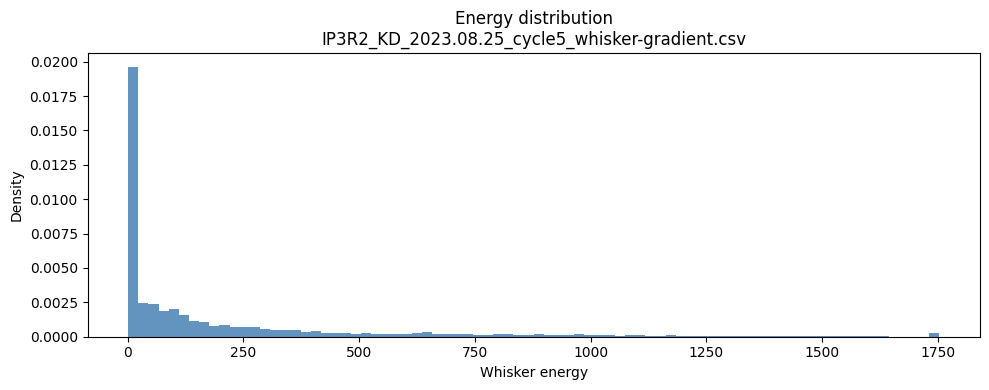

[ok] IP3R2_KD_2023.08.25_cycle5_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=464.2170


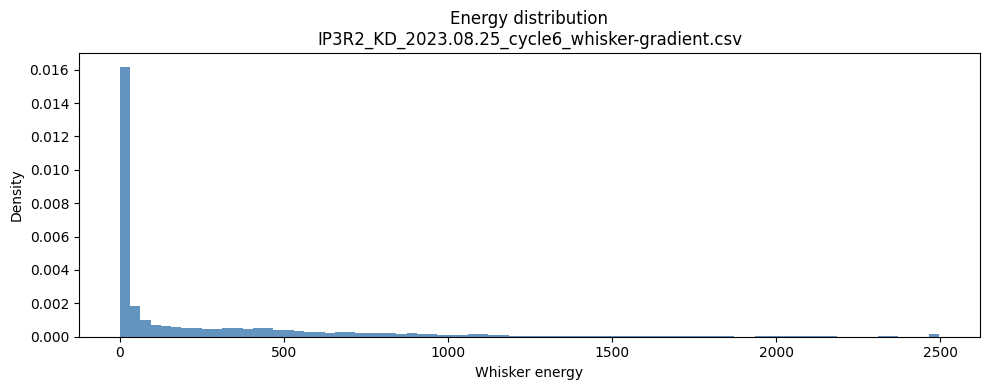

[ok] IP3R2_KD_2023.08.25_cycle6_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=353.3879


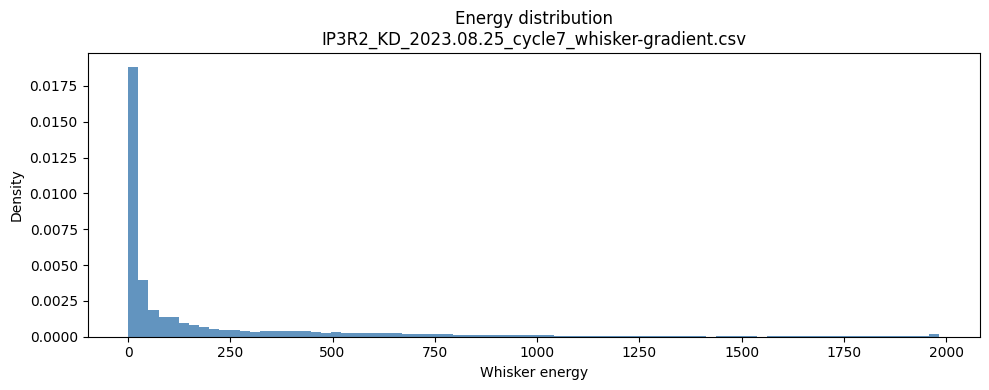

[ok] IP3R2_KD_2023.08.25_cycle7_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=126.8068


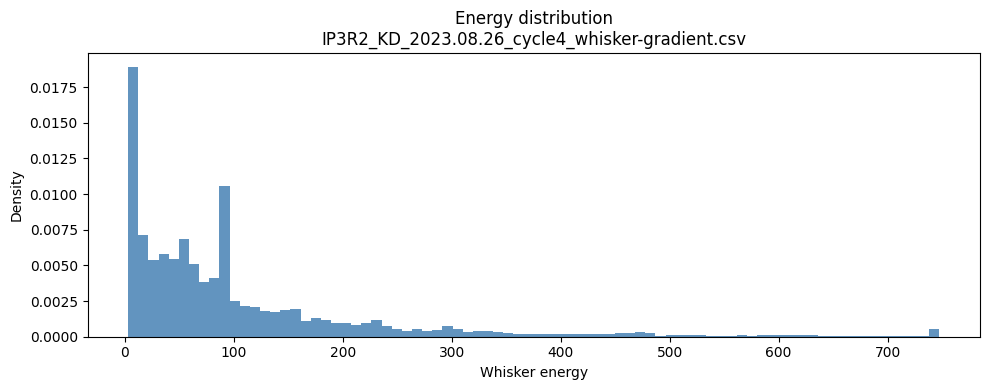

[ok] IP3R2_KD_2023.08.26_cycle4_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=620.4585


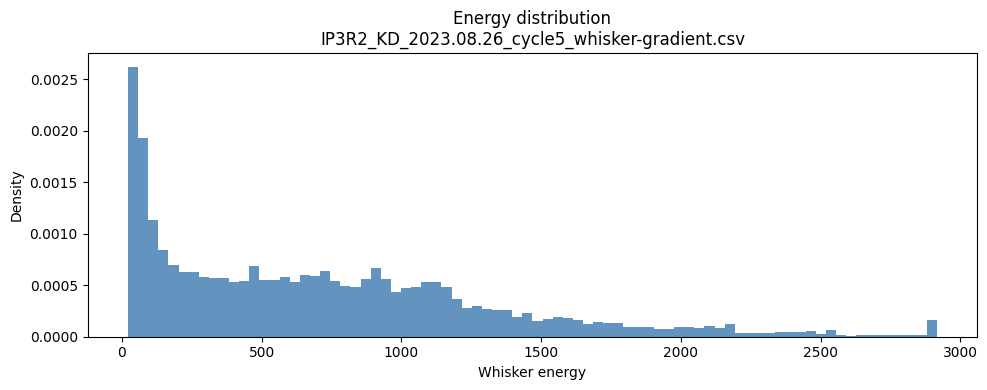

[ok] IP3R2_KD_2023.08.26_cycle5_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=103.7797


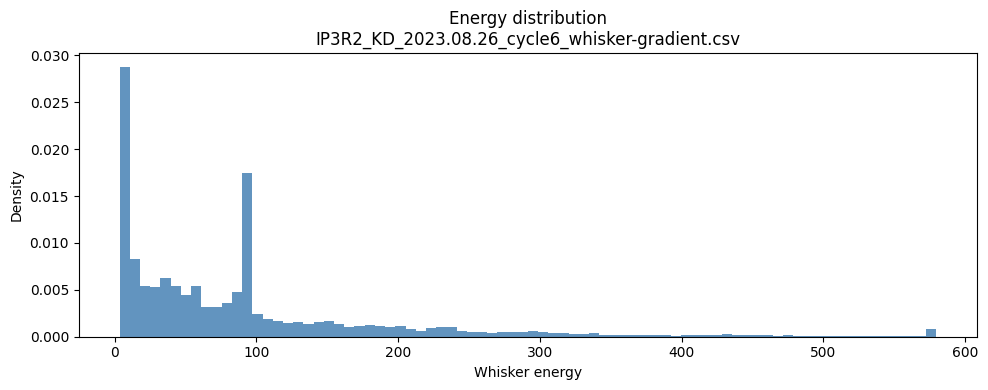

[ok] IP3R2_KD_2023.08.26_cycle6_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=192.0753


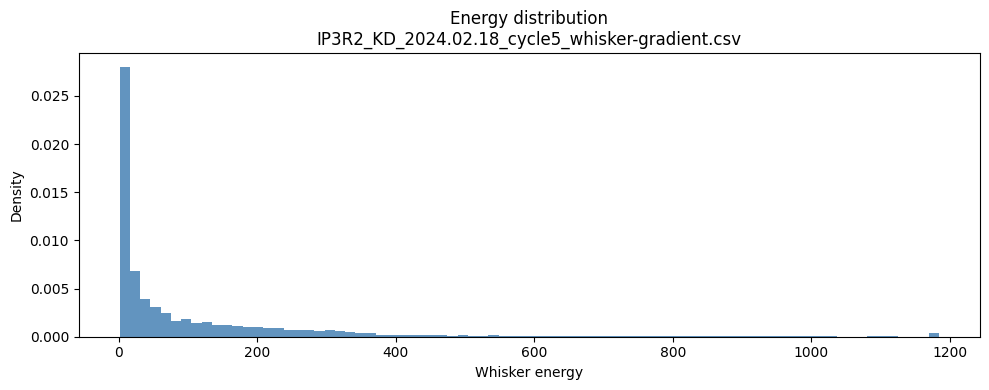

[ok] IP3R2_KD_2024.02.18_cycle5_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=214.5197


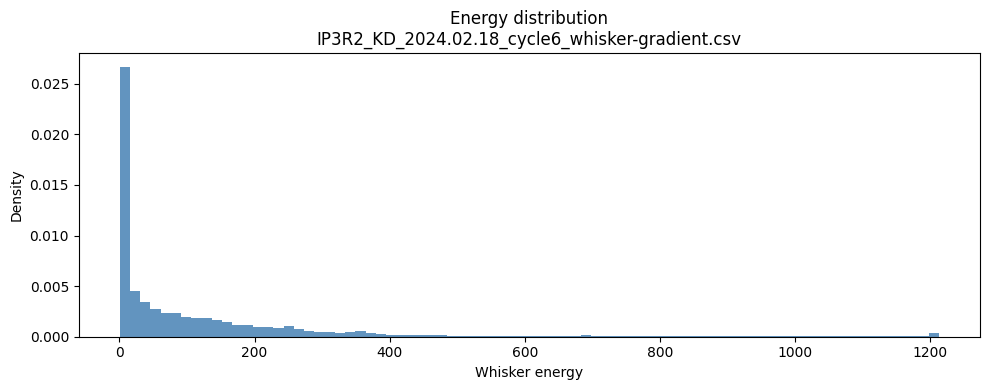

[ok] IP3R2_KD_2024.02.18_cycle6_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=313.5527


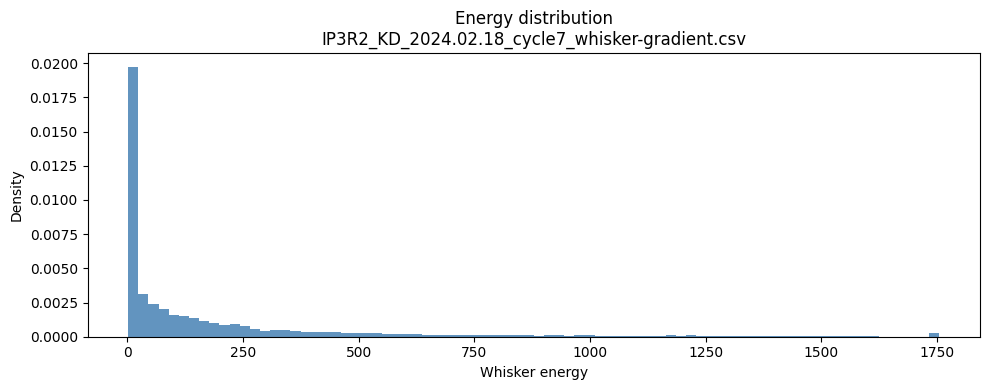

[ok] IP3R2_KD_2024.02.18_cycle7_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=250.5740


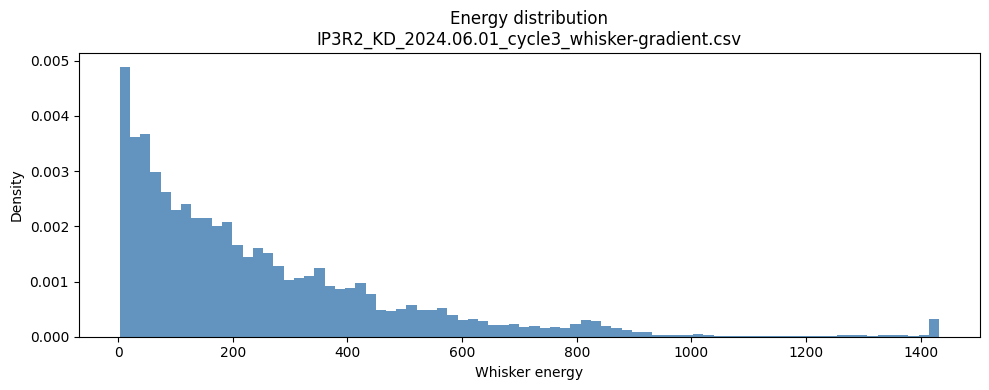

[ok] IP3R2_KD_2024.06.01_cycle3_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=145.6472


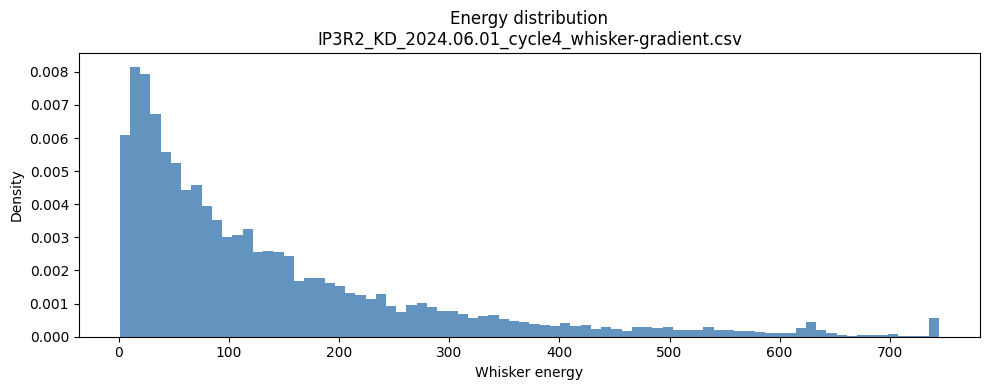

[ok] IP3R2_KD_2024.06.01_cycle4_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=543.1567


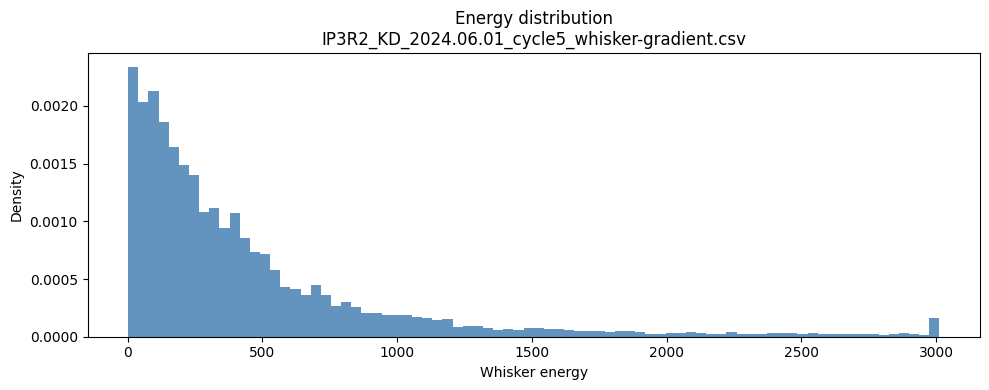

[ok] IP3R2_KD_2024.06.01_cycle5_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=435.4497


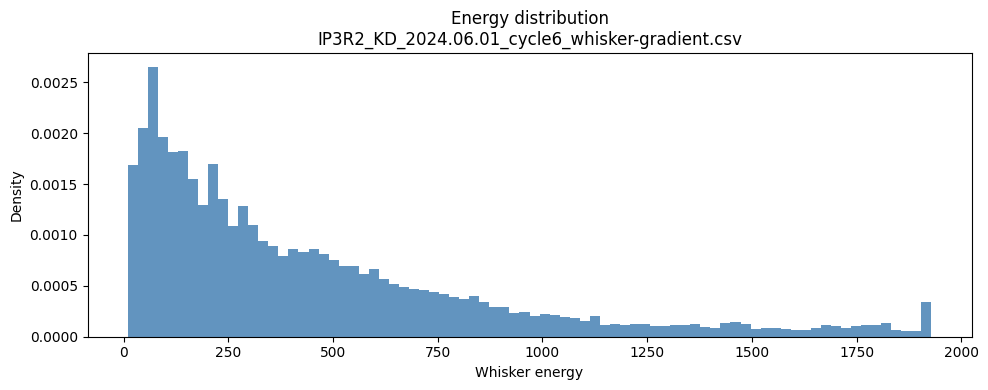

[ok] IP3R2_KD_2024.06.01_cycle6_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=422.2145


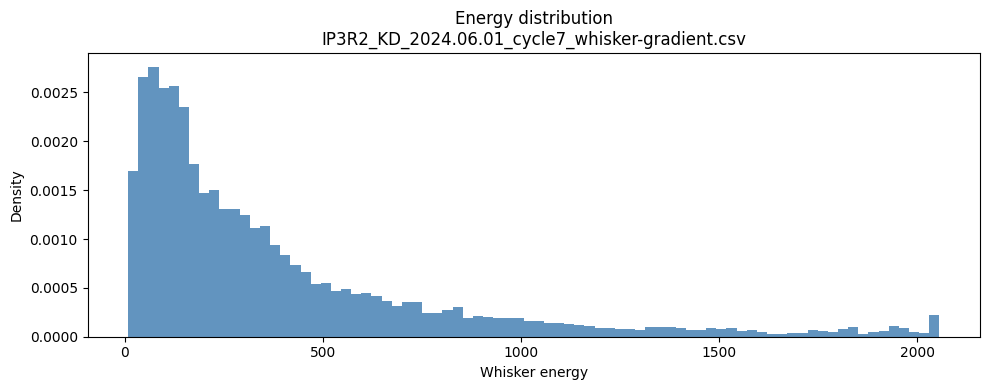

[ok] IP3R2_KD_2024.06.01_cycle7_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=1376.4019


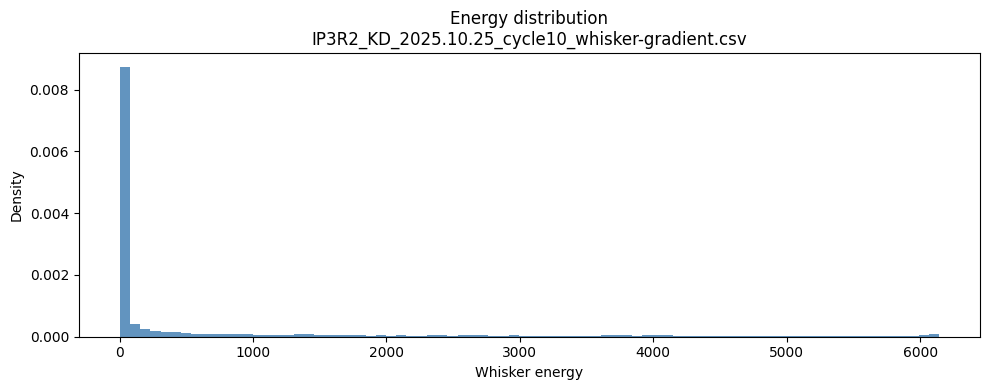

[ok] IP3R2_KD_2025.10.25_cycle10_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=1865.3295


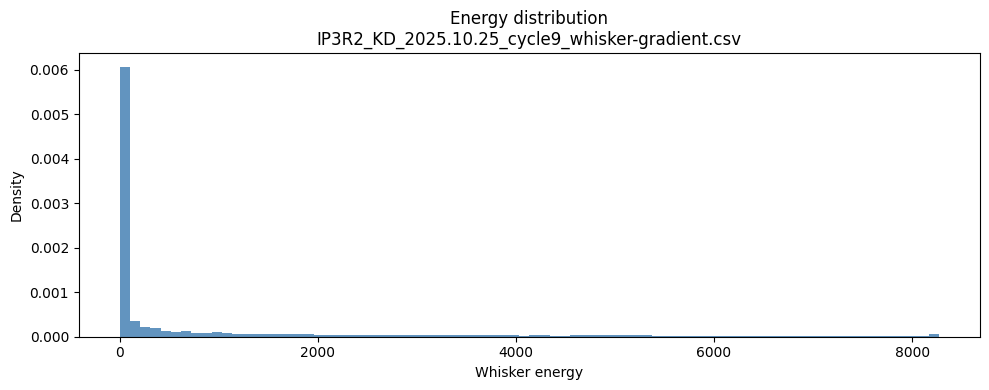

[ok] IP3R2_KD_2025.10.25_cycle9_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=57.8422


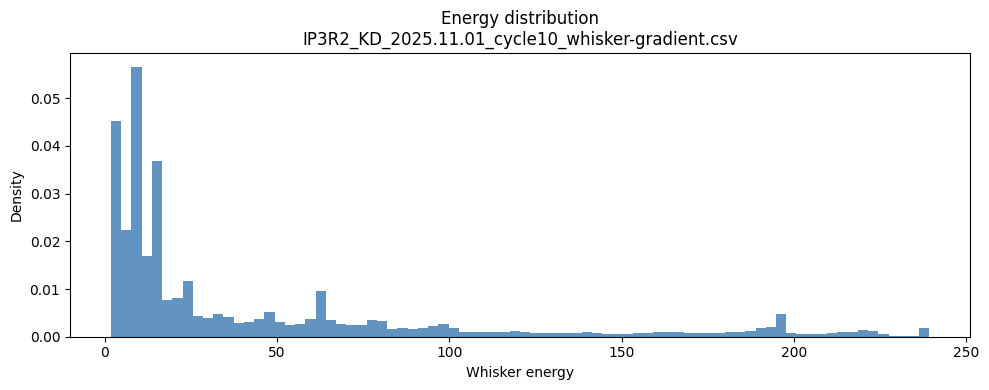

[ok] IP3R2_KD_2025.11.01_cycle10_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=45.5431


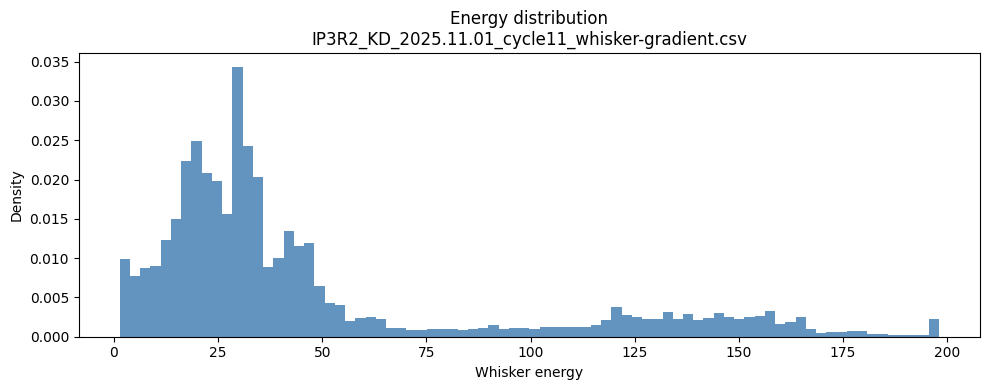

[ok] IP3R2_KD_2025.11.01_cycle11_whisker-gradient.csv: n_energy=45001
[whisker] fs=50.000 win=50 sigma=15 out_std=45.1142


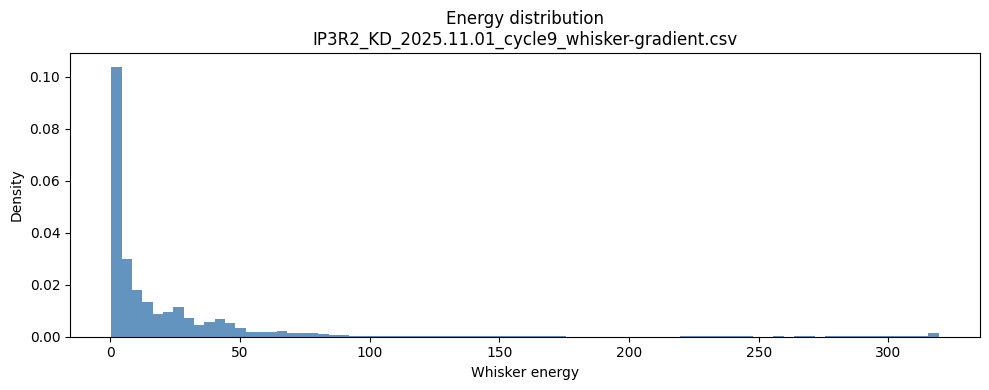

[ok] IP3R2_KD_2025.11.01_cycle9_whisker-gradient.csv: n_energy=45001


In [21]:
res = plot_whisker_energy_distributions_from_pattern(
    "data/pupil_whisker_arteriole/IP3R2_KD_*_*_whisker-gradient.csv",
    fs=50.0,
    max_time=900.0,
    window_sec=1.0,
    smooth_sec=0.3,
    bins=80,
    clip_percentiles=(0.5, 99.5),
    verbose=True,
)

In [22]:
import os
import glob
import numpy as np
import pandas as pd

def estimate_floor_percentile(energy, p=1.0, eps=1e-12):
    e = np.asarray(energy, float)
    e = e[np.isfinite(e) & (e > eps)]
    if e.size == 0:
        return np.nan
    return float(np.nanpercentile(e, p))

def print_whisker_energy_floors_from_pattern(
    whisker_glob_pattern,
    floor_percentile=1.0,
    fs=50.0,
    max_time=900.0,
    window_sec=1.0,
    smooth_sec=0.3,
    eps=1e-12,
    verbose=False,
):
    paths = sorted(glob.glob(whisker_glob_pattern))
    if len(paths) == 0:
        raise FileNotFoundError(f"No files matched pattern: {whisker_glob_pattern}")

    floors = []
    for path in paths:
        try:
            w_df = pd.read_csv(path)
            t_grid, v_grid = standardize_whisker_to_grid(w_df, fs=float(fs), max_time=float(max_time), verbose=verbose)
            energy = get_whisker_energy_from_trace(
                t_grid, v_grid, window_sec=float(window_sec), smooth_sec=float(smooth_sec), verbose=verbose
            )
            if energy is None:
                floor = np.nan
            else:
                floor = estimate_floor_percentile(energy, p=float(floor_percentile), eps=eps)
        except Exception:
            floor = np.nan

        label = os.path.basename(path)
        print(f"{label}\tfloor_p{floor_percentile:g}={floor}")
        floors.append({"path": path, "label": label, "floor": floor})

    return floors

In [ ]:
floors = print_whisker_energy_floors_from_pattern(
    "data/pupil_whisker_arteriole/*_whisker-gradient.csv",
    floor_percentile=0.5,   # try 0.5, 1.0, 2.0
    fs=50.0,
    max_time=900.0,
    window_sec=1.0,
    smooth_sec=0.3,
)

IP3R2_KD_2023.08.25_cycle5_whisker-gradient.csv	floor_p0.5=1.0000000000000002
IP3R2_KD_2023.08.25_cycle6_whisker-gradient.csv	floor_p0.5=0.3801371093716389
IP3R2_KD_2023.08.25_cycle7_whisker-gradient.csv	floor_p0.5=0.09018727318312435
IP3R2_KD_2023.08.26_cycle4_whisker-gradient.csv	floor_p0.5=3.004466796728346
IP3R2_KD_2023.08.26_cycle5_whisker-gradient.csv	floor_p0.5=21.594165260451877
IP3R2_KD_2023.08.26_cycle6_whisker-gradient.csv	floor_p0.5=3.475084825632907
IP3R2_KD_2024.02.18_cycle5_whisker-gradient.csv	floor_p0.5=1.7508396442002407
IP3R2_KD_2024.02.18_cycle6_whisker-gradient.csv	floor_p0.5=0.42620902326589477
IP3R2_KD_2024.02.18_cycle7_whisker-gradient.csv	floor_p0.5=1.6494902219266527
IP3R2_KD_2024.06.01_cycle3_whisker-gradient.csv	floor_p0.5=2.887148028506572
IP3R2_KD_2024.06.01_cycle4_whisker-gradient.csv	floor_p0.5=0.7906871956947281
IP3R2_KD_2024.06.01_cycle5_whisker-gradient.csv	floor_p0.5=2.0382915456079487
IP3R2_KD_2024.06.01_cycle6_whisker-gradient.csv	floor_p0.5=9.7228

### Event-aligned multimodal group stats (clean events)

Run from project root (same env as this notebook: `pandas`, `matplotlib`, `numpy`):

```bash
python scripts/event_aligned_analysis.py
```

Or in-notebook (project root on `sys.path`):

```python
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))
from event_aligned_analysis import run_event_aligned_group_analysis
run_event_aligned_group_analysis(verbose=True)
```

Outputs: `data/analysis/event_metrics.csv`, `data/figures/group_psth_*.png`, metric comparison PNGs.
